# Chung cư, khu đô thị, khách sạn lớn, resort — tập trung gian

Notebook này tách khỏi `eda-poi.ipynb`, chỉ xử lý **mảng công trình / nơi ở & lưu trú**.

Đầu vào: `data/qa/critique/poi_extended_7tinh.parquet` (193.509 POI của 7 tỉnh trọng điểm).
Đầu ra: `data/qa/eda/poi_building_7tinh.parquet` — tập **trung gian**, ưu tiên recall, còn nhiễu, là nguyên liệu cho bản final.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

EDA_DIR = ROOT / "data/qa/eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)

# Bộ 7 TỈNH trọng điểm. Đổi sang "vn" để chạy toàn quốc (410.426 POI, ~25 phút) —
# schema hai bộ khớp nhau nên không phải sửa gì khác.
SCOPE = "7tinh"
poi = pq.read_table(ROOT / f"data/qa/critique/poi_extended_{SCOPE}.parquet").to_pandas()

# Khoá thực thể: osm_id trần va chạm giữa node và way — mọi phép so/loại về sau dùng uid.
poi["uid"] = poi["osm_type"].astype(str) + ":" + poi["osm_id"].astype(str)

print(f"poi: {len(poi):,} dòng, {poi.shape[1]} cột")
# Nếu KHÔNG có relation ở đây thì các KĐT multipolygon đã mất từ upstream —
# notebook không cứu được, phải quay lại bước trích xuất.
print("osm_type:", poi["osm_type"].value_counts().to_dict())
print(f"{poi['province_name'].nunique()} tỉnh/thành")
print(poi["province_name"].value_counts().head(10).to_string())

poi: 193,509 dòng, 29 cột
osm_type: {'node': 111273, 'way': 80414, 'relation': 1822}
7 tỉnh/thành
province_name
Thành phố Hồ Chí Minh    61404
Thành phố Hà Nội         57894
Thành phố Đà Nẵng        22969
Tỉnh Đồng Nai            19527
Thành phố Hải Phòng      12288
Thành phố Cần Thơ        11707
Tỉnh Quảng Ninh           7720


## Chung cư, khu đô thị

### Bước 1: filter MỎNG, ưu tiên recall

Mục tiêu của bước này là **không bỏ sót** chung cư / khu đô thị nào; nhiễu được chấp nhận và sẽ lọc ở bước sau.

Lý do phải lai *tag + tên*: trong 1.010 POI có "chung cư" trong tên chỉ 42% có `building=*`, và với "khu đô thị/KĐT" chỉ 14% — 244 POI không mang **bất kỳ** tag cấu trúc nào. Riêng lọc theo tag sẽ mất chính những khu lớn nhất (nhóm brand Vinhomes/Masteri/Ecopark… có tới 77% không có `building`).

Chuẩn hoá tên: bỏ dấu + hạ chữ, vì dữ liệu có cả "chung cu" / "khu do thi" không dấu. Quét cả `name:vi`, `name:en`, `alt_name`, `old_name` chứ không chỉ `name`.

In [2]:
def parse_tags(x):
    """tags → dict; chịu được NaN / chuỗi hỏng / đã là dict."""
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return json.loads(x)
        except json.JSONDecodeError:
            return {}
    return {}


# Parse MỘT lần, mọi cell sau dùng lại cột này.
# Hai chỗ parse bằng hai hàm khác nhau là hai nguồn sự thật — bảng con sẽ lệch bảng mẹ.
poi["tags_dict"] = poi["tags"].map(parse_tags)

# Xem toàn bộ key và số lần xuất hiện
tag_keys = poi["tags_dict"].map(list).explode().value_counts()
print(tag_keys)

tags_dict
name                                92581
amenity                             46063
power                               31376
landuse                             28736
building                            26918
                                    ...  
gated_community                         1
contact:sms                             1
width                                   1
communication:amateur_radio:wwff        1
watch:repair                            1
Name: count, Length: 1498, dtype: int64


In [3]:
import re
import unicodedata


def strip_accents(s: str) -> str:
    """Hạ chữ + bỏ dấu tiếng Việt (đ/Đ xử lý riêng vì NFD không tách được)."""
    s = unicodedata.normalize("NFD", str(s)).replace("đ", "d").replace("Đ", "D")
    return re.sub(r"[̀-ͯ]", "", s).lower()


td = poi["tags_dict"]

# các key chưa được bung ở poi_extended nhưng cần cho lớp công trình
poi["residential"] = td.map(lambda t: t.get("residential"))
poi["construction"] = td.map(lambda t: t.get("construction"))
poi["place"] = td.map(lambda t: t.get("place"))
poi["levels"] = pd.to_numeric(td.map(lambda t: t.get("building:levels")), errors="coerce")
poi["rooms"] = pd.to_numeric(td.map(lambda t: t.get("rooms")), errors="coerce")
poi["stars"] = td.map(lambda t: t.get("stars"))
poi["operator"] = td.map(lambda t: t.get("operator"))
poi["brand"] = td.map(lambda t: t.get("brand"))

# gộp mọi biến thể tên: OSM hay để tên tiếng Việt ở name:vi / alt_name / old_name
alt_names = td.map(
    lambda t: " ".join(v for v in (t.get("name:vi"), t.get("name:en"), t.get("alt_name"), t.get("old_name")) if v)
)
poi["name_norm"] = (poi["name"].fillna("").map(strip_accents) + " " + alt_names.map(strip_accents)).str.strip()
name_norm = poi["name_norm"]

# --- nhánh A: tag cấu trúc ---
HOUSING_TAG = (
    poi["building"].isin(["apartments", "residential", "dormitory", "terrace", "house"])
    | poi["residential"].isin(["apartments", "dormitory", "block", "urban", "estate", "gated", "terrace"])
    | poi["landuse"].eq("residential")
    | poi["place"].isin(["neighbourhood", "quarter", "city_block"])
    # DỰ ÁN NHÀ Ở ĐANG XÂY: `landuse=construction` + `construction=residential|apartments`.
    # Bước 1 phải tuyển — nguyên tắc của bước này là KHÔNG BỎ SÓT, quyết định giữ/bỏ là
    # việc của bước 3. Không tuyển thì 439 ha nguồn cung nhà ở tương lai biến mất không dấu
    # vết, lẫn vào mọi công trường khác. Ở đây có Hinode Royal Park (102,7 ha),
    # GS Metrocity Long Bình (58 ha) — không phải nhiễu.
    | poi["construction"].isin(["residential", "apartments", "dormitory", "terrace", "house"])
)

# --- nhánh B: từ khoá tên (đã bỏ dấu) ---
# `chcc` (chung cư cao cấp) và `kdtm?` (KĐT + KĐTM): hai viết tắt mà bản regex đầu bỏ sót —
# \bkdt\b không khớp "kdtm" vì đòi ranh giới từ ngay sau chữ t.
HOUSING_RX = (
    # chung cư & biến thể nhà ở tập trung
    r"chung ?cu|\bchcc\b|cu xa|tap the|\bktt\b|cao oc|to hop|can ho|khu can ho|apartment|residence|residential|condo"
    r"|nha o xa hoi|noxh|tai dinh cu|\btdc\b|ky tuc xa|\bktx\b|dormitory"
    # cách gọi nhà ở mà đầu dò độc lập bắt được (regex đầu không có)
    r"|nha cong vu|du an nha o|nha o can bo|khu biet thu|khu villa"
    # khu đô thị / khu dân cư
    r"|khu do thi|\bkdtm?\b|khu dan cu|\bkdc\b|khu nha o|\bcity\b|garden city|riverside"
    # cách gọi toà/block và mã toà kiểu HH4, CT12, N05
    r"|\btower|\bthap\b|\btoa\b|\bblock\b|\bhh\d|\bct\d|\bn0\d"
    # brand chủ đầu tư — nhóm bỏ sót nặng nhất nếu chỉ lọc theo tag.
    # Danh sách ĐÓNG, nghiêng Hà Nội — trần recall không đo được; hướng thay thế đúng là
    # tự nuôi từ vựng từ tên các POI có tag cứng (xem cell rà không gian âm bên dưới).
    r"|vinhomes|masteri|ecopark|times city|royal city|goldmark|the manor|sunshine|gamuda"
    r"|ciputra|park hill|smart city|ocean park|celadon|midtown"
)
HOUSING_NAME = name_norm.str.contains(HOUSING_RX, regex=True, na=False)

# --- nhánh W: whitelist duyệt tay ---
# Quy trình: cell rà hình thái bên dưới xuất ứng viên → duyệt trên bản đồ → dán `uid`
# (mỗi dòng một uid) vào file này → chạy lại notebook. Việc này là của NGƯỜI: toà văn
# phòng và toà chung cư cùng hình thái, OSM không cho thêm dấu hiệu nào để máy tách.
WHITELIST_PATH = EDA_DIR / f"whitelist_chungcu_{SCOPE}.txt"
whitelist_uids = set(WHITELIST_PATH.read_text().split()) if WHITELIST_PATH.exists() else set()
WHITELIST = poi["uid"].isin(whitelist_uids)
if whitelist_uids:
    print(f"nhánh whitelist: khớp {WHITELIST.sum():,} / {len(whitelist_uids)} uid trong {WHITELIST_PATH.name}\n")

poi["is_housing"] = HOUSING_TAG | HOUSING_NAME | WHITELIST

print(f"nhánh tag  : {HOUSING_TAG.sum():,}")
print(
    f"nhánh tên  : {HOUSING_NAME.sum():,}   (trong đó {(HOUSING_NAME & ~HOUSING_TAG).sum():,} KHÔNG có tag cấu trúc → tag-only sẽ mất)"
)
print(
    f"hợp        : {poi['is_housing'].sum():,} / {len(poi):,} ({poi['is_housing'].mean():.1%})"
)
print()
print(poi.loc[poi["is_housing"], "province_name"].value_counts().to_string())

nhánh tag  : 15,110
nhánh tên  : 4,510   (trong đó 1,823 KHÔNG có tag cấu trúc → tag-only sẽ mất)
hợp        : 16,933 / 193,509 (8.8%)

province_name
Thành phố Hồ Chí Minh    7462
Thành phố Hà Nội         5301
Thành phố Đà Nẵng        1711
Thành phố Hải Phòng       818
Tỉnh Đồng Nai             773
Thành phố Cần Thơ         523
Tỉnh Quảng Ninh           345


In [4]:
# Kiểm chứng recall: quét phần BỊ LOẠI bằng các mẫu chữ rộng hơn regex tuyển,
# nếu còn sót POI nhà ở thật thì phải nới HOUSING_RX trước khi đi tiếp.
excluded = poi[~poi["is_housing"]]
print(f"phần bị loại: {len(excluded):,} dòng, {excluded.shape[1]} cột")

print("== Rà soát phần bị loại ==")
for pat in ["chung cu", "chcc", "do thi", "kdtm", "can ho", "tap the", "cu xa", "tai dinh", "ktx", "apartment", "nha o"]:
    hit = excluded["name_norm"].str.contains(pat, na=False)
    if hit.sum():
        samples = excluded.loc[hit, "name"].dropna().head(3).tolist()
        print(f"  '{pat}': {hit.sum():>3} → {samples}")

# Đối chứng độ phủ trên các tag "chắc chắn là nhà ở": phải đạt 100%
for col, val in [("building", "apartments"), ("building", "dormitory"), ("landuse", "residential")]:
    m = poi[col].eq(val)
    print(f"\nphủ {col}={val}: {(m & poi['is_housing']).sum():,}/{m.sum():,}")

print("\n== Nhiễu đã biết, để xử lý ở bước sau ==")
print("- 'đô thị' còn sót đều là Công ty Môi trường/Thoát nước Đô thị → đúng là không phải KĐT")
print("- place=neighbourhood/quarter là node hành chính, không phải công trình")
print("- landuse=residential có polygon tới 2.216 ha (area_outlier), cần chặn ngưỡng trên")
print("- building=apartments lẫn 'nhà trọ', 'Lô A1/A2/B3' → 1 chung cư bị vẽ thành nhiều toà")

phần bị loại: 176,576 dòng, 40 cột
== Rà soát phần bị loại ==
  'do thi':  47 → ['Công Ty Môi Trường Đô Thị Sơn Tây', 'Phòng Quản lý đô thị', 'Công ty Thoát nước Đô thị']
  'tai dinh':   1 → ['Đình An Tài']
  'nha o':  30 → ['Nhà ở', 'Nhà ở', 'Nhà ông Chửng']

phủ building=apartments: 4,573/4,573

phủ building=dormitory: 321/321

phủ landuse=residential: 4,665/4,665

== Nhiễu đã biết, để xử lý ở bước sau ==
- 'đô thị' còn sót đều là Công ty Môi trường/Thoát nước Đô thị → đúng là không phải KĐT
- place=neighbourhood/quarter là node hành chính, không phải công trình
- landuse=residential có polygon tới 2.216 ha (area_outlier), cần chặn ngưỡng trên
- building=apartments lẫn 'nhà trọ', 'Lô A1/A2/B3' → 1 chung cư bị vẽ thành nhiều toà


In [5]:
# Rà KHÔNG GIAN ÂM bằng HÌNH THÁI — tín hiệu ĐỘC LẬP với regex, để bắt unknown-unknowns.
# Cổng recall ở trên kiểm bằng chính họ từ khoá đã dùng để tuyển, nên nó không thể phát
# hiện một chung cư không tag, không keyword. Hình thái thì không nói dối: polygon
# building=*, ≥8 tầng, mặt bằng 300–20.000 m², không mang tag chức năng nào khác.
#
# Nới từ building=yes sang building=* (bản đầu chỉ thấy 1 dòng vì tự giới hạn =yes).
# Nhóm này LẪN toà văn phòng không tách máy được → XUẤT ĐI DUYỆT TAY, không auto-tuyển:
# dòng nào đúng là chung cư thì thêm `uid` vào whitelist (nhánh W ở cell tuyển phía trên).
FUNC_KEYS = {"amenity", "shop", "office", "tourism", "leisure", "man_made", "historic",
             "highway", "public_transport", "railway", "power", "natural", "craft"}
morph = (
    ~poi["is_housing"]
    & poi["building"].notna()
    & (poi["levels"] >= 8)
    & poi["is_area"]
    & poi["area_m2"].between(300, 20_000)
    & ~poi["tags_dict"].map(lambda t: bool(FUNC_KEYS & t.keys()))
)
print(f"hình thái toà cao mà KHÔNG được tuyển: {morph.sum():,} dòng")
print(poi.loc[morph, ["uid", "name", "building", "levels", "area_m2", "province_name"]].head(15).to_string())
print(f"\ntrong đó KHÔNG có tên: {poi.loc[morph, 'name'].isna().mean():.0%} — phải soi trên bản đồ")

out_review = EDA_DIR / f"poi_morph_review_{SCOPE}.parquet"
poi.loc[morph].drop(columns="tags_dict").to_parquet(out_review, index=False)
print(f"\n→ {out_review.name}: xem bằng  make poi-proxy SRC=data/qa/eda/{out_review.name}")
print(f"  dòng là chung cư → thêm uid vào {WHITELIST_PATH.name} rồi chạy lại notebook")

hình thái toà cao mà KHÔNG được tuyển: 104 dòng
                  uid                                                                                                              name    building  levels      area_m2          province_name
111862  way:136247707                                                                                                                S4     college    14.0   958.767886       Thành phố Hà Nội
112222  way:158465668                                                                                                                D8  university    11.0  1405.406672       Thành phố Hà Nội
112341  way:165491082                                                                                                      Times Square  commercial    40.0  3545.266358  Thành phố Hồ Chí Minh
112390  way:166142092                                                                                                               NaN  university    10.0   779.507010  Thành phố Hồ C

### Buớc 2: Dive in vào các class

Chung cư chúng ta sẽ có nhiều dạng ngoài việc chung cư chỉ có chứng năng là chuưn cư thì vẫn có các chung cư hay toà nhà có nhiều chức năng như chưng cư + siêu thị, hay chung cư + văn phòng

Do đó với các dạng toàn nhà thế này thì tôi sẽ ưu tiên chung cư là lọc toàn bộ phần còn lại

Ở bước này sẽ gộp cả các loại như nhà ở chung, như khu tập thể, khu tái định khu, ...

In [6]:
housing = poi[poi["is_housing"]].copy()
t = housing["name_norm"]

# --- A. tag nói thẳng "nhà ở tập trung" ---
A_TAG = (
    housing["building"].isin(["apartments", "dormitory"])
    | housing["residential"].isin(["apartments", "dormitory", "block", "terrace"])
    | housing["construction"].isin(["apartments", "dormitory"])
)

# --- B. tên nói thẳng: gộp mọi biến thể nhà ở chung (tập thể, cư xá, TĐC, NOXH, KTX) ---
B_NAME = t.str.contains(
    r"chung ?cu|\bchcc\b|cu xa|tap the|\bktt\b|can ho|\bapartment|condo|residence|cao oc"
    r"|nha o xa hoi|noxh|tai dinh cu|\btdc\b|ky tuc xa|\bktx\b|dormitory",
    na=False,
)

# --- C. mã toà chung cư kiểu HH4A / CT12 / N05 (Linh Đàm, Mỹ Đình, Xa La...) ---
C_CODE = t.str.contains(r"\bhh\d|\bct\d|\bn0\d", na=False)

# --- D. khu đô thị / khu dân cư ---
D_KDT = (
    t.str.contains(r"khu do thi|\bkdtm?\b|khu dan cu|\bkdc\b|khu nha o|garden city", na=False)
    | housing["landuse"].eq("residential")
    | housing["residential"].eq("urban")
    # dự án đang xây quy mô KHU — định tuyến để tới được bước 3, không rơi vào BO
    | housing["construction"].isin(["residential", "terrace", "house"])
)

# --- E. token chỉ hình dạng: toà/tháp/tower/block ---
E_SHAPE = t.str.contains(r"\btower|\bthap\b|\btoa\b|\bblock\b|riverside|to hop|\bcity\b", na=False)

label = pd.Series("BO", index=housing.index)

# Thứ tự gán = thứ tự ưu tiên. Toà hỗn hợp (chung cư + siêu thị / + văn phòng) rơi vào
# A/B trước nên luôn được nhận là CHUNG_CU, bất kể có shop/office/amenity gì kèm theo.
# --- W. whitelist duyệt tay — bằng chứng NGƯỜI, xếp trên mọi nhánh máy ---
W_MANUAL = housing["uid"].isin(whitelist_uids)

for cond, val in [
    (W_MANUAL, "CHUNG_CU"),
    (A_TAG | B_NAME, "CHUNG_CU"),
    (C_CODE, "CHUNG_CU"),
    (D_KDT, "KHU_DO_THI"),
    (E_SHAPE, "CHUNG_CU"),
]:
    label[cond & label.eq("BO")] = val

housing["label"] = label

# Ghi lại NGUỒN TUYỂN — dữ kiện "nhánh nào khớp", KHÔNG phải điểm tin cậy.
# Ở đây chưa lọc nhiễu nên chưa có căn cứ nào để chấm điểm đúng/sai; việc đánh giá
# chất lượng chỉ có nghĩa sau bước lọc, dựa trên bằng chứng (có tag công trình, là
# polygon, có building:levels...) chứ không dựa trên regex nào đã bắt được dòng đó.
housing["src_tag"] = A_TAG
housing["src_name"] = B_NAME
housing["src_code"] = C_CODE
housing["src_kdt"] = D_KDT
housing["src_shape"] = E_SHAPE
housing["src_manual"] = W_MANUAL

# Bậc bằng chứng cho downstream tự chọn độ tin: tag cứng > tên nói thẳng > chỉ token hình dạng.
housing["evidence"] = np.select(
    [W_MANUAL, A_TAG, B_NAME | C_CODE | D_KDT],
    ["manual", "hard_tag", "explicit_name"],
    default="token_only",
)

print(housing["label"].value_counts().to_string())
print("\nnguồn tuyển (một dòng có thể khớp nhiều nguồn):")
for c in ["src_tag", "src_name", "src_code", "src_kdt", "src_shape", "src_manual"]:
    print(f"  {c:12s} {housing[c].sum():6,}")
print("\nbậc bằng chứng:")
print(housing["evidence"].value_counts().to_string())

label
CHUNG_CU      7401
BO            5536
KHU_DO_THI    3996

nguồn tuyển (một dòng có thể khớp nhiều nguồn):
  src_tag       5,769
  src_name      1,726
  src_code        474
  src_kdt       5,031
  src_shape     1,921
  src_manual        0

bậc bằng chứng:
evidence
token_only       6482
hard_tag         5769
explicit_name    4682


In [7]:
# Cổng recall: MỌI dấu hiệu chung cư / KĐT đều phải nằm ngoài nhóm BO. Mất 1 dòng là fail.
CHECKS = {
    "building=apartments": housing["building"].eq("apartments"),
    "building=dormitory": housing["building"].eq("dormitory"),
    "residential=apartments": housing["residential"].eq("apartments"),
    "residential=urban": housing["residential"].eq("urban"),
    "landuse=residential": housing["landuse"].eq("residential"),
    "tên 'chung cư'": t.str.contains(r"chung ?cu", na=False),
    "tên 'CHCC'": t.str.contains(r"\bchcc\b", na=False),
    "tên 'tập thể|cư xá'": t.str.contains(r"tap the|cu xa", na=False),
    "tên 'tái định cư|TĐC'": t.str.contains(r"tai dinh cu|\btdc\b", na=False),
    "tên 'KTX|ký túc xá'": t.str.contains(r"\bktx\b|ky tuc xa", na=False),
    # neo biên: "can ho" trần khớp nhầm "Can Hoạch"
    "tên 'căn hộ|apartment'": t.str.contains(r"\bcan ho\b|\bapartment", na=False),
    "tên 'nhà ở xã hội'": t.str.contains(r"nha o xa hoi|noxh", na=False),
    "tên 'khu đô thị|KĐT|KĐTM'": t.str.contains(r"khu do thi|\bkdtm?\b", na=False),
    "mã toà HH/CT/N0": C_CODE,
}

lost_total = 0
for check_name, m in CHECKS.items():
    lost = (m & housing["label"].eq("BO")).sum()
    lost_total += lost
    print(f"  {check_name:26s} giữ {(m & ~housing['label'].eq('BO')).sum():>5,}/{m.sum():<5,}  mất {lost}")
assert lost_total == 0, f"recall thủng: mất {lost_total} dòng"
print(f"\n✓ recall 100% trên {len(CHECKS)} phép thử")

# Nhóm BO là gì — phải toàn thứ không phải nhà ở tập trung
dropped = housing[housing["label"].eq("BO")]
print(f"\nBO: {len(dropped):,} dòng | {dropped['place'].notna().mean():.0%} là node place hành chính")
print("  building còn lại:", dropped["building"].value_counts().head(6).to_dict())
print("  mẫu tên:", dropped["name"].dropna().head(8).tolist())

  building=apartments        giữ 4,573/4,573  mất 0
  building=dormitory         giữ   321/321    mất 0
  residential=apartments     giữ   824/824    mất 0
  residential=urban          giữ   102/102    mất 0
  landuse=residential        giữ 4,665/4,665  mất 0
  tên 'chung cư'             giữ 1,024/1,024  mất 0
  tên 'CHCC'                 giữ     0/0      mất 0
  tên 'tập thể|cư xá'        giữ   193/193    mất 0
  tên 'tái định cư|TĐC'      giữ    50/50     mất 0
  tên 'KTX|ký túc xá'        giữ   133/133    mất 0
  tên 'căn hộ|apartment'     giữ   214/214    mất 0
  tên 'nhà ở xã hội'         giữ    22/22     mất 0
  tên 'khu đô thị|KĐT|KĐTM'  giữ   308/308    mất 0
  mã toà HH/CT/N0            giữ   474/474    mất 0

✓ recall 100% trên 14 phép thử

BO: 5,536 dòng | 96% là node place hành chính
  building còn lại: {'house': 70, 'terrace': 23, 'residential': 20, 'yes': 12, 'office': 1, 'hotel': 1}
  mẫu tên: ['Vĩnh Bảo', 'Phả Lại', 'Lai Cách', 'Tiên Lãng', 'Bến Tắm', 'Hòa Thọ Đông', 'G

In [8]:
# CỔNG RECALL ĐỘC LẬP — cổng ở trên tự kiểm bằng chính họ từ khoá đã dùng để tuyển,
# nên về mặt logic nó KHÔNG THỂ trượt: một cổng không bao giờ đỏ là một cổng vô dụng.
# Cổng này dò phần BỊ LOẠI bằng những tín hiệu KHÔNG nằm trong luật tuyển. Nó có quyền đỏ.
#
# Ba họ đầu dò, mỗi họ độc lập với luật:
#   1. TAG vòng đời / biến thể mà luật không đọc (construction:*, abandoned:*, was:*)
#   2. TỪ VỰNG tiếng Việt rộng hơn regex tuyển
#   3. HÌNH THÁI: toà cao mà tag building KHÔNG tự khai là loại khác
_bo = poi[~poi["is_housing"]]
_bo_ten = _bo["name_norm"]
_bo_tags = _bo["tags_dict"]

BLACKLIST_BUILDING = {
    "church", "office", "commercial", "industrial", "retail", "school", "university", "hospital",
    "government", "warehouse", "train_station", "kiosk", "hut", "shed", "garage", "garages",
    "house", "roof", "construction", "service", "civic", "public", "temple", "mosque", "stadium",
    "hangar", "greenhouse", "farm", "barn", "transportation", "college", "kindergarten",
    "sports_hall", "supermarket", "bunker", "toilets", "carport", "hotel", "tower", "museum",
}

# ── ĐẦU DÒ CỨNG: mỗi dòng bắt được là một LỖ CÓ THỂ VÁ trong luật tuyển ⇒ assert = 0 ──
DAU_DO_CUNG = {
    "tag vòng đời = nhà ở": _bo_tags.map(
        lambda t: any(
            k.split(":")[-1] in {"building", "landuse"}
            and str(v) in {"apartments", "residential", "dormitory", "terrace"}
            for k, v in t.items()
        )
    ),
    "tên: nhà ở công vụ/dự án": _bo_ten.str.contains(r"nha cong vu|du an nha o|nha o can bo", na=False),
    "tên: khu biệt thự": _bo_ten.str.contains(r"khu biet thu|khu villa", na=False),
    "tên: chung cư mini": _bo_ten.str.contains(r"chung cu mini|cc mini", na=False),
}

# ── ĐẦU DÒ MỀM: nhiễu KHÔNG KHỬ ĐƯỢC bằng luật, chỉ theo dõi ⇒ báo cáo, không assert ──
# Một toà `building=yes` cao 12 tầng có thể là chung cư, khách sạn, hay thư viện — OSM
# không cho thêm dấu hiệu nào. Nếu assert nhóm này thì cổng đỏ vĩnh viễn, tức lại vô dụng
# đúng như cổng vòng tròn ở trên, chỉ ngược dấu. Việc của nó là ĐO ĐỘ TRÔI giữa các lần chạy.
DAU_DO_MEM = {
    "tên: apartment sai chính tả (đa số là lưu trú)": _bo_ten.str.contains(
        r"appartment|apartement|aparment", na=False
    ),
    "hình thái: toà ≥8 tầng, building=yes — mơ hồ tự thân": (
        _bo["building"].notna()
        & ~_bo["building"].isin(BLACKLIST_BUILDING)
        & (_bo["levels"] >= 8)
        & _bo["is_area"]
        & _bo["area_m2"].between(300, 20_000)
    ),
}

_thung = 0
print("── ĐẦU DÒ CỨNG (phải bằng 0) ──")
for _ten, _m in DAU_DO_CUNG.items():
    _n = int(_m.sum())
    _thung += _n
    _vd = _bo.loc[_m, "name"].dropna().head(3).tolist() if _n else []
    print(f"  {'✗' if _n else '✓'} {_ten:52s} sót {_n:4,}  {_vd}")

print("\n── ĐẦU DÒ MỀM (theo dõi, không chặn) ──")
for _ten, _m in DAU_DO_MEM.items():
    _n = int(_m.sum())
    _vd = _bo.loc[_m, "name"].dropna().head(3).tolist() if _n else []
    print(f"  ⊙ {_ten:52s} {_n:4,}  {_vd}")

assert _thung == 0, f"recall thủng {_thung} dòng ở đầu dò CỨNG — soi lại HOUSING_TAG / HOUSING_RX"
print("\n✓ cổng độc lập: mọi đầu dò cứng = 0")

── ĐẦU DÒ CỨNG (phải bằng 0) ──
  ✓ tag vòng đời = nhà ở                                 sót    0  []
  ✓ tên: nhà ở công vụ/dự án                             sót    0  []
  ✓ tên: khu biệt thự                                    sót    0  []
  ✓ tên: chung cư mini                                   sót    0  []

── ĐẦU DÒ MỀM (theo dõi, không chặn) ──
  ⊙ tên: apartment sai chính tả (đa số là lưu trú)          6  ['Pallet Aparment', 'Cherry Hotel & Appartments', 'Han Appartment']
  ⊙ hình thái: toà ≥8 tầng, building=yes — mơ hồ tự thân   97  ['Khách sạn Caravelle Saigon', 'Thư viện Tạ Quang Bửu', 'Shang Garden']

✓ cổng độc lập: mọi đầu dò cứng = 0


In [9]:
candidates = housing[housing["label"].ne("BO")].copy()

COLS = [
    "uid", "osm_type", "osm_id", "is_area", "lat", "lng", "area_m2", "geometry_wkb", "h3_r8",
    "name", "name_norm",
    "building", "residential", "construction", "landuse", "place", "amenity", "shop", "office", "tourism", "leisure",
    "levels", "operator", "brand",
    "area_outlier", "dup_coord", "province_code", "province_name",
    "label", "evidence",
    # nguồn tuyển: dữ kiện nhánh nào khớp, để truy ngược khi một nhánh hoá ra hỏng
    "src_tag", "src_name", "src_code", "src_kdt", "src_shape", "src_manual",
    "n_tags", "tags", "tags_dict",
]
candidates = candidates[COLS]

out_path = EDA_DIR / f"poi_chungcu_{SCOPE}.parquet"
# tags_dict là cột dict chỉ dùng trong RAM — bản ghi đĩa giữ chuỗi `tags` gốc
candidates.drop(columns="tags_dict").to_parquet(out_path, index=False)

print(f"poi_chungcu: {len(candidates):,} dòng, {candidates.shape[1] - 1} cột → {out_path}\n")
print(candidates["label"].value_counts().to_string())
print()
print(candidates.groupby("label")["province_name"].value_counts().unstack(0).fillna(0).astype(int).to_string())
print(f"\npolygon {candidates['is_area'].mean():.0%} | có name {candidates['name'].notna().mean():.0%}"
      f" | có levels {candidates['levels'].notna().mean():.0%} | area_outlier {candidates['area_outlier'].sum():,}")

poi_chungcu: 11,397 dòng, 38 cột → /home/n91ym1nhky/Work/internVSF/evcs-atlas/data/qa/eda/poi_chungcu_7tinh.parquet

label
CHUNG_CU      7401
KHU_DO_THI    3996

label                  CHUNG_CU  KHU_DO_THI
province_name                              
Thành phố Cần Thơ           159         301
Thành phố Hà Nội           3328        1379
Thành phố Hải Phòng         117         225
Thành phố Hồ Chí Minh      3158         592
Thành phố Đà Nẵng           333        1333
Tỉnh Quảng Ninh             119         128
Tỉnh Đồng Nai               187          38

polygon 89% | có name 57% | có levels 17% | area_outlier 139


In [10]:
candidates

,uid,osm_type,osm_id,is_area,lat,lng,area_m2,geometry_wkb,h3_r8,name,...,evidence,src_tag,src_name,src_code,src_kdt,src_shape,src_manual,n_tags,tags,tags_dict
101,node:369486734,node,369486734,False,10.773726,106.716601,NaN,None,8865b56667fffff,Thành phố Hồ Chí Minh,...,token_only,False,False,False,False,True,False,189,"{""alt_name"": ""Sài Gòn"", ""alt_name:en"": ""Saigon...","{'alt_name': 'Sài Gòn', 'alt_name:en': 'Saigon..."
265,node:444394752,node,444394752,False,20.999853,105.815113,NaN,None,88415cb4d1fffff,Tòa nhà King Palace - 108 Nguyễn Trãi,...,token_only,False,False,False,False,True,False,8,"{""bench"": ""no"", ""bin"": ""no"", ""bus"": ""yes"", ""hi...","{'bench': 'no', 'bin': 'no', 'bus': 'yes', 'hi..."
337,node:446044211,node,446044211,False,21.002032,105.861295,NaN,None,88415cb411fffff,Tập thể E6 Quỳnh Mai - Kim Ngưu,...,explicit_name,False,True,False,False,False,False,4,"{""bus"": ""yes"", ""highway"": ""bus_stop"", ""name"": ...","{'bus': 'yes', 'highway': 'bus_stop', 'name': ..."
2289,node:738813535,node,738813535,False,21.036548,105.782044,NaN,None,8841436965fffff,Tòa nhà Indochina Tower - Đối diện ĐHQG Hà Nội,...,token_only,False,False,False,False,True,False,8,"{""bench"": ""yes"", ""bin"": ""no"", ""bus"": ""yes"", ""h...","{'bench': 'yes', 'bin': 'no', 'bus': 'yes', 'h..."
2290,node:738813552,node,738813552,False,21.007534,105.802711,NaN,None,88415cb499fffff,Nhà 24T2 KĐT Trung Hoà Nhân Chính - Hoàng Đạo ...,...,explicit_name,False,False,False,True,False,False,5,"{""bus"": ""yes"", ""departures_board"": ""yes"", ""hig...","{'bus': 'yes', 'departures_board': 'yes', 'hig..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193477,way:1540903516,way,1540903516,True,10.777133,106.658399,8085.697435,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,8865b566e7fffff,Chung cư Bưu Điện,...,hard_tag,True,True,False,True,False,False,5,"{""addr:province"": ""Thành phố Hồ Chí Minh"", ""ad...","{'addr:province': 'Thành phố Hồ Chí Minh', 'ad..."
193478,way:1540903517,way,1540903517,True,10.776901,106.658682,748.562663,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",8865b566e7fffff,NaN,...,hard_tag,True,False,False,False,False,False,1,"{""building"": ""apartments""}",{'building': 'apartments'}
193479,way:1540903518,way,1540903518,True,10.777159,106.658440,769.838863,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,8865b566e7fffff,NaN,...,hard_tag,True,False,False,False,False,False,1,"{""building"": ""apartments""}",{'building': 'apartments'}
193480,way:1540903519,way,1540903519,True,10.777448,106.658192,770.187931,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,8865b566e7fffff,NaN,...,hard_tag,True,False,False,False,False,False,1,"{""building"": ""apartments""}",{'building': 'apartments'}


### Bước 3: Bắt đầu tìm insight, rà kĩ dataset

Có một số insight xuất hiện như sau cho các row không phải là chung cư, khu đô thị:
- toà: thường có các keyword như toà án, toà nhà hành chính, 
- một số transport station có dạng như: đối diện toà nhà(xuất hiên rất nhiều, thường có tên là đối diện ngoài ra còn có tags: public transport)
- nhà: nhà riêng, nhà thờ, nhà nước(kho bạc nhà nước), nhà thi đấu
- tháp truyền hình
- ubnd, winmart+(winmart)
- một số tags như: tourism, bus_stop
- ngoài ra thì có các field như: leisure, amenity

In [11]:
# Bước 3 — xoá cái CHẮC CHẮN SAI, mỗi luật một cell, chạy tuần tự.
#
# Nguyên tắc: tag mô tả VẬT THỂ, tên chỉ mô tả MỐC THAM CHIẾU.
# Node `highway=bus_stop` tên "Chung cư Ngô Gia Tự" vẫn là trạm buýt — "chung cư" ở đây
# là tên trạm, không phải bằng chứng có toà nhà. Nên tên KHÔNG được phép cứu tag.
#
# 14 luật GIAO HOÁN: mỗi điều kiện chỉ đọc thuộc tính bất biến của dòng (tag, tên), không
# luật nào đọc kết quả của luật khác ⇒ tập bị xoá = HỢP của 14 điều kiện, đổi thứ tự cell
# không đổi kết quả. Thứ tự chỉ quyết định `drop_reason` gán cho dòng khớp NHIỀU luật
# (78% dòng chỉ bị đúng một luật bắt). Tính chất này là thứ cho phép song song hoá khi
# đóng thành ETL. Vẫn phải chạy từ cell này xuống vì `remaining` co dần theo từng cell.

for k in ["highway", "public_transport", "man_made", "historic", "natural", "waterway",
          "power", "aeroway", "railway", "barrier", "craft", "construction"]:
    candidates[k] = candidates["tags_dict"].map(lambda x, k=k: x.get(k))

remaining = candidates.copy()
remaining["mixed_use"] = False  # toà nhà ở có chức năng khác ở tầng đế — xem drop_rule()
removed_parts = []


def has_hard_housing_tag(df):
    """Bằng chứng nhà ở CỨNG — dùng để cảnh báo khi một luật đang xoá quá tay."""
    return df["building"].isin(["apartments", "dormitory"]) | df["residential"].isin(
        ["apartments", "dormitory", "block"]
    )


def preview(cond, title, cols=None, n=10):
    """Xem trước một luật SẼ xoá gì, chưa xoá."""
    hit = remaining[cond.reindex(remaining.index, fill_value=False)]
    cols = cols or ["name", "building", "is_area"]
    print(f"{title}: {len(hit):,} dòng")
    print(hit[cols].head(n).to_string())
    return hit


def drop_rule(cond, rule, n=6, tha_toa_hon_hop=False):
    """Xoá khỏi `remaining`, ghi vào `removed_parts`, in bằng chứng để soi ngay tại chỗ.

    `tha_toa_hon_hop=True` cho các luật bắt theo tag CHỨC NĂNG (amenity/shop/leisure):
    khi một object mang ĐỒNG THỜI tag nhà ở cứng và tag chức năng, người map đã nhập hai
    vật thể làm một. Nếu là POLYGON thì hình học là bằng chứng VẬT LÝ của một toà, còn
    quán/tiệm chỉ là đơn vị thuê tầng đế ⇒ GIỮ toà, cắm cờ `mixed_use`. Nếu là NODE thì
    không có toà nào cả, node đó chính là điểm dịch vụ ⇒ vẫn xoá.

    KHÔNG áp cho lưu trú (LUẬT 5/6): `tourism=hotel` + `building=apartments` là khách sạn
    căn hộ — quyết định đã chốt là thuộc lớp lưu trú, không phải mâu thuẫn cần gỡ.
    """
    global remaining
    m = cond.reindex(remaining.index, fill_value=False)

    if tha_toa_hon_hop:
        tha = m & has_hard_housing_tag(remaining) & remaining["is_area"]
        if tha.any():
            remaining.loc[tha, "mixed_use"] = True
            print(f"  ⊙ {tha.sum()} POLYGON nhà ở + tag chức năng → GIỮ, cờ mixed_use:",
                  remaining.loc[tha, "name"].dropna().head(5).tolist())
            m = m & ~tha

    hit = remaining[m]
    print(f"{rule}: xoá {len(hit):,}  →  còn lại {len(remaining) - len(hit):,}")
    print("  mẫu :", hit["name"].dropna().head(n).tolist())

    # cảnh báo: dòng vừa xoá lại mang tag nhà ở cứng → luật có thể đang quá tay
    conflict = hit[has_hard_housing_tag(hit)]
    if len(conflict):
        print(f"  ⚠ {len(conflict)} dòng có tag nhà ở cứng:", conflict["name"].dropna().head(8).tolist())

    removed_parts.append(hit.assign(drop_reason=rule))
    remaining = remaining[~m]


print(f"vào bước 3: {len(remaining):,} dòng")

vào bước 3: 11,397 dòng


In [12]:
# Soi giá trị thực tế của từng tag trước khi viết luật — đừng đoán danh sách giá trị.
for k in ["highway", "public_transport", "railway", "aeroway", "man_made", "historic",
          "natural", "waterway", "power", "barrier", "craft"]:
    vals = remaining[k].dropna().value_counts()
    print(f"{k:18s} {vals.sum():5,} → {vals.head(8).to_dict()}")

highway              592 → {'bus_stop': 592}
public_transport     598 → {'platform': 590, 'stop_position': 7, 'station': 1}
railway               10 → {'stop': 7, 'yard': 3}
aeroway                2 → {'tower': 2}
man_made              31 → {'tower': 24, 'wastewater_plant': 3, 'works': 1, 'stupa': 1, 'storage_tank': 1, 'water_tower': 1}
historic              10 → {'memorial': 4, 'ruins': 3, 'city_gate': 2, 'monument': 1}
natural                2 → {'coastline': 2}
waterway               0 → {}
power                  1 → {'pole': 1}
barrier               17 → {'fence': 9, 'wall': 8}
craft                  2 → {'electrician': 1, 'caterer': 1}


In [13]:
# LUẬT 1 — hạ tầng đường: trạm buýt, ke ga, đường ray, tháp không lưu.
# Đây là luật ăn nhiều nhất, và là luật quan trọng nhất: 143 POI tên có "chung cư"
# nằm ở đây, tất cả đều là TÊN TRẠM BUÝT lấy chung cư làm mốc.
#
# `barrier` KHÔNG nằm trong luật này: `barrier=wall/fence` là tường rào QUANH khu chung cư,
# đưa vào sẽ xoá cả Vinhomes Times City, The Marq, The Opera Residence.

INFRA = (
    remaining["highway"].notna()
    | remaining["public_transport"].notna()
    | remaining["railway"].notna()
    | remaining["aeroway"].notna()
)

print("tên có 'chung cư' mà dính luật này:")
print(remaining[INFRA & remaining["name_norm"].str.contains("chung ?cu", na=False)][
    ["name", "highway", "public_transport"]].head(8).to_string())
print()

drop_rule(INFRA, "HA_TANG_DUONG")

tên có 'chung cư' mà dính luật này:
                                     name   highway public_transport
2368           Chung cư A3B 92 Thanh Nhàn  bus_stop         platform
8360                 Chung cư Nguyễn Trãi  bus_stop         platform
8399  Trạm Xe Bus Chung Cư Lý Thường Kiệt  bus_stop         platform
9144                      Chung cư Gò Dầu  bus_stop         platform
9186                  Chung cư Ngô Gia Tự  bus_stop         platform
9266                       Chung cư Manor  bus_stop         platform
9377                       Chung cư Conic  bus_stop         platform
9622                          Chung cư C7  bus_stop         platform

HA_TANG_DUONG: xoá 605  →  còn lại 10,792
  mẫu : ['Tòa nhà King Palace - 108 Nguyễn Trãi', 'Tập thể E6 Quỳnh Mai - Kim Ngưu', 'Tòa nhà Indochina Tower - Đối diện ĐHQG Hà Nội', 'Nhà 24T2 KĐT Trung Hoà Nhân Chính - Hoàng Đạo Thúy', 'Đối diện nhà 24T2 KĐT Trung Hoà Nhân Chính - Hoàng Đạo Thúy', 'Đối diện nhà N2E Khu đô thị Trung Hòa Nhân Chín

In [14]:
# LUẬT 2 — amenity: mọi giá trị amenity đều là chức năng KHÁC chức năng ở.
# Toà án, công an, nhà thờ, trường, bệnh viện, quán ăn, ATM... Chung cư thật hầu như
# không mang amenity — chỉ 2/5.753 POI có tag nhà ở cứng đồng thời có amenity.
print(remaining["amenity"].value_counts().head(12).to_dict())
print()

drop_rule(remaining["amenity"].notna(), "AMENITY_KHAC", tha_toa_hon_hop=True)

{'courthouse': 94, 'restaurant': 27, 'place_of_worship': 25, 'cafe': 18, 'community_centre': 17, 'university': 17, 'school': 14, 'townhall': 11, 'police': 10, 'hospital': 7, 'parking': 6, 'library': 6}

  ⊙ 2 POLYGON nhà ở + tag chức năng → GIỮ, cờ mixed_use: ['Tokyo Deli Tran Hung Dao', 'Công an phường An Phú Đông']
AMENITY_KHAC: xoá 291  →  còn lại 10,501
  mẫu : ['Nhà Hàng Riverside Saigon', 'Bảo Minh Tower', 'KTX Bệnh viện ĐHY', 'Riverside 3', 'Cà Phê City House', 'Hanoi Creative City']


In [15]:
# LUẬT 3 — cửa hàng / văn phòng / xưởng thủ công.
# Bắt được WinMart+ và các tạp hoá THUÊ trong chung cư: POI là cửa hàng, không phải toà.
# Cũng bắt sàn giao dịch BĐS `office=estate_agent` mang tên dự án ("Chung Cư Sunshine
# Diamond River") — đó là văn phòng bán hàng, không phải chung cư.
SHOP_OFFICE = remaining["shop"].notna() | remaining["office"].notna() | remaining["craft"].notna()
print(remaining[SHOP_OFFICE][["name", "shop", "office"]].head(8).to_string())
print()

drop_rule(SHOP_OFFICE, "SHOP_OFFICE", tha_toa_hon_hop=True)

                                         name         shop office
12445             Vincom Mega Mall Royal City         mall    NaN
13225     Cửa Hàn Thú Cưng Volantis Free City          pet    NaN
14726             Trung Tâm Mua Sắm Vivo City  supermarket    NaN
15183         Trung tâm mua sắm KDC viet-sing  supermarket    NaN
15814                             Siêu thị V+  supermarket    NaN
18611                   Trạm điện KTX mở rộng          NaN    NaN
18635                       Phòng ANCT SV KTX          NaN    yes
18652  Family Mart Ký Túc Xá Đại Học Quốc Giá  convenience    NaN

  ⊙ 3 POLYGON nhà ở + tag chức năng → GIỮ, cờ mixed_use: ['Nội thất Go Home - Gò Vấp', 'Công ty TNHH MTV Quản lý và Phát triển nhà Hà Nội', 'HT beauty']
SHOP_OFFICE: xoá 162  →  còn lại 10,339
  mẫu : ['Vincom Mega Mall Royal City', 'Cửa Hàn Thú Cưng Volantis Free City', 'Trung Tâm Mua Sắm Vivo City', 'Trung tâm mua sắm KDC viet-sing', 'Siêu thị V+', 'Trạm điện KTX mở rộng']


In [16]:
# LUẬT 4 — leisure: công viên, sân bãi, phòng gym, bể bơi.
print(remaining["leisure"].value_counts().head(10).to_dict())
print()

drop_rule(remaining["leisure"].notna(), "LEISURE", tha_toa_hon_hop=True)

{'park': 32, 'playground': 8, 'swimming_pool': 5, 'pitch': 4, 'fitness_centre': 3, 'resort': 3, 'sports_centre': 3, 'stadium': 2, 'amusement_arcade': 1, 'fitness_station': 1}

LEISURE: xoá 63  →  còn lại 10,276
  mẫu : ['Phòng Tập California Fitness & Yoga', 'White Pearl Apartment', 'Phòng Tập City Gym', 'Tập thể 829', 'Công viên Chung cư Phú An', 'Công Viên Chung cư Sunview Town']


In [17]:
# LUẬT 5 — lưu trú: khách sạn, hostel, resort
# GIỮ LẠI `tourism=apartment`: đó là căn hộ dịch vụ, vắt giữa chung cư và lưu trú,
# chưa quyết phía nào — sẽ chốt MỘT lần ở lớp khách sạn/resort (nhánh lưu trú cuối
# notebook cũng trỏ về đúng quyết định đó, không quyết riêng).
# NGOẠI LỆ KTX — phát hiện nhờ chuông giá trị lạ của LUẬT 6: OSM VN hay gắn
# `tourism=hostel` (và guest_house) cho KÝ TÚC XÁ sinh viên. Hostel = lưu trú ngắn hạn,
# KTX = nơi ở dài hạn — tag OSM không phân biệt được hai thứ, nên luật này đang giết
# nhà ở thật ("Khu Ký túc xá B" 2,3 ha ở ĐHQG, "KTX D1 + D2").
#
# Vì sao ở đây tên ĐƯỢC PHÉP cứu tag, không phá nguyên tắc chung: nguyên tắc "tên chỉ là
# mốc tham chiếu" sinh ra từ NODE (trạm buýt tên "Chung cư X" nằm CẠNH chung cư). Với
# POLYGON thì tên đang mô tả CHÍNH vật thể được vẽ — không có vật thể thứ hai để trỏ tới.
# Nên chỉ tha polygon, và chỉ với từ tiếng Việt không thể hiểu thành lưu trú thương mại.
KTX_POLYGON = remaining["is_area"] & remaining["name_norm"].str.contains(
    r"\bktx\b|ky tuc xa|tap the|cu xa", na=False
)
LODGING = remaining["tourism"].notna() & remaining["tourism"].ne("apartment") & ~KTX_POLYGON
print(remaining["tourism"].value_counts().head(10).to_dict())
tha_ktx = remaining["tourism"].notna() & remaining["tourism"].ne("apartment") & KTX_POLYGON
if tha_ktx.any():
    print(f"\n⊙ tha {tha_ktx.sum()} polygon KTX/tập thể mang tag lưu trú:")
    print(remaining.loc[tha_ktx, ["name", "tourism", "area_m2"]].to_string())
print()

drop_rule(LODGING, "LUU_TRU")

{'hotel': 104, 'apartment': 64, 'hostel': 18, 'guest_house': 13, 'attraction': 5, 'museum': 4, 'artwork': 3, 'viewpoint': 3, 'chalet': 2, 'wilderness_hut': 1}

⊙ tha 3 polygon KTX/tập thể mang tag lưu trú:
                   name tourism       area_m2
112443      KTX D1 + D2  hostel    807.382714
112479      KTX D1 + D2  hostel    441.838768
112514  Khu Ký túc xá B  hostel  23322.776530

LUU_TRU: xoá 153  →  còn lại 10,123
  mẫu : ['Khách Sạn Riverside Saigon', 'Emerald Hoi An Riverside Resort', 'Long Life Riverside', 'Riverside Bamboo Resort', 'City view', 'Khách Sạn Marriotte Ibiz City Hotel']
  ⚠ 3 dòng có tag nhà ở cứng: ['Sơn Tịnh', 'Nami Hotel & Apartments', 'Mermaid Seaside']


In [18]:
# LUẬT 6 — building nói thẳng đây là loại công trình khác.
# Gồm `house` = nhà riêng lẻ, không phải nhà ở chung.
# `hotel`/`tower`/`museum` thêm vào sau khi soi: 5 dòng lọt lưới vì building=hotel/tower/museum
# không nằm trong danh sách cũ — "H Tower 197/195" (building=hotel, 12 tầng), "Areca Riverside
# Hotel" (building=hotel), "Bến Dược Memorial Temple Tower" (building=tower — tháp tưởng niệm),
# "Tòa Cánh diều"/"Tòa Trống đồng" (building=museum, building:use=cultural — Bảo tàng Dân tộc học).
#
# Áp dụng KHÔNG điều kiện, đúng nguyên tắc "không miễn nhiễm": building=hotel cũng xoá cả
# "Pham Thanh Apartment", "Oakwood Residence Saigon", "Rest Hotel & Apartment" dù tên chứa
# apartment/residence — tag nói building này LÀ khách sạn, tên chỉ là thương hiệu kinh doanh.
print(remaining["building"].value_counts().head(15).to_dict())

BUILDING_OTHER_VALUES = ["church", "office", "commercial", "industrial", "retail", "school", "university",
     "hospital", "government", "warehouse", "train_station", "kiosk", "hut", "shed",
     "garage", "garages", "house", "roof", "construction", "service", "civic", "public",
     "temple", "mosque", "stadium", "hangar", "greenhouse", "farm", "barn",
     "transportation", "college", "kindergarten", "sports_hall", "supermarket",
     "bunker", "toilets", "carport", "hotel", "tower", "museum"]
BUILDING_OTHER = remaining["building"].isin(BUILDING_OTHER_VALUES)
# CHUÔNG giá trị lạ: blacklist là danh sách ĐÓNG, giá trị chưa biết hiện được GIỮ IM LẶNG.
# Trên 7 tỉnh chỉ còn `mixed_use` (giữ là đúng); chạy tỉnh khác mà chuông kêu thì phải
# phân loại giá trị mới trước khi tin kết quả.
BUILDING_BIET = set(BUILDING_OTHER_VALUES) | {"apartments", "residential", "dormitory",
                                              "terrace", "yes", "mixed_use"}
la = remaining.loc[remaining["building"].notna() & ~remaining["building"].isin(BUILDING_BIET), "building"]
print("⚑ building CHƯA PHÂN LOẠI:", la.value_counts().to_dict() or "không có")
print()

drop_rule(BUILDING_OTHER, "BUILDING_KHAC")

{'apartments': 4570, 'dormitory': 321, 'office': 115, 'commercial': 67, 'university': 35, 'school': 17, 'yes': 16, 'hotel': 6, 'hospital': 3, 'retail': 2, 'museum': 2, 'public': 1, 'monument': 1, 'government': 1, 'tower': 1}
⚑ building CHƯA PHÂN LOẠI: {'monument': 1, 'no': 1, 'storage_tank': 1}

BUILDING_KHAC: xoá 251  →  còn lại 9,872
  mẫu : ['Khu Dân Cư Prince', 'Tháp Hà Nội', 'Tòa Nhà Saigon Tower', 'Sở Giao dịch chứng khoán Thành phố Hồ Chí Minh', 'Toà Nhà Saigon Trade Center', 'Petro Tower']


In [19]:
# LUẬT 6B — DỰ ÁN NHÀ Ở ĐANG XÂY. Đặt TRƯỚC luật landuse để có lý do loại RIÊNG:
# nhóm này bị loại vì CHƯA CÓ CƯ DÂN, không phải vì "landuse sai". Tách ra thì
# `bi_xoa[drop_reason == "DU_AN_DANG_XAY"]` trả lời được ngay câu "nguồn cung nhà ở
# tương lai ở đâu, bao nhiêu ha" — câu mà bài toán trạm sạc sẽ cần.
DANG_XAY = remaining["construction"].isin(["residential", "apartments", "dormitory", "terrace", "house"])
print(f"tổng diện tích dự án đang xây: {remaining.loc[DANG_XAY, 'area_m2'].sum() / 1e4:,.0f} ha")
print(remaining[DANG_XAY].nlargest(5, "area_m2")[["name", "construction", "area_m2", "province_name"]].to_string())
print()

drop_rule(DANG_XAY, "DU_AN_DANG_XAY")

tổng diện tích dự án đang xây: 3,819 ha
                                       name construction       area_m2          province_name
193418  Khu đô thị du lịch lấn biển Cần Giờ  residential  2.891080e+07  Thành phố Hồ Chí Minh
192193                VinHomes Hạ Long Xanh  residential  4.358937e+06        Tỉnh Quảng Ninh
156898                    Hinode Royal Park  residential  1.027269e+06       Thành phố Hà Nội
159083               GS Metrocity Long Bình  residential  5.815790e+05  Thành phố Hồ Chí Minh
159084               GS Metrocity Long Bình  residential  3.529535e+05  Thành phố Hồ Chí Minh

DU_AN_DANG_XAY: xoá 83  →  còn lại 9,789
  mẫu : ['Vinhomes The Gallery', 'Triton Crown Phú Mỹ Hưng', 'Dự án nhà ở Cán bộ', 'One Opera Complex', 'Nhà BTS Dũng', 'Ruby Precinct']
  ⚠ 1 dòng có tag nhà ở cứng: ['Ruby Precinct']


In [20]:
# LUẬT 7 — landuse không phải đất ở.
# Lưu ý `construction`: dự án chưa xây (Vinhomes Wonder City) — chưa có người ở nên
# chưa thuộc lớp này, nhưng đáng ghi nhớ nếu sau này cần dự báo nhu cầu tương lai.
print(remaining["landuse"].value_counts().head(12).to_dict())

LANDUSE_OTHER_VALUES = ["industrial", "commercial", "retail", "cemetery", "construction", "forest",
     "farmland", "military", "religious", "quarry", "grass", "orchard", "meadow",
     "brownfield", "greenfield", "landfill", "allotments", "recreation_ground", "basin",
     "aquaculture", "farmyard", "plant_nursery", "salt_pond", "flowerbed", "paddy",
     "railway", "garages", "education", "reservoir"]
LANDUSE_OTHER = remaining["landuse"].isin(LANDUSE_OTHER_VALUES)

la = remaining.loc[
    remaining["landuse"].notna() & ~remaining["landuse"].isin(set(LANDUSE_OTHER_VALUES) | {"residential"}),
    "landuse",
]
print("⚑ landuse CHƯA PHÂN LOẠI:", la.value_counts().to_dict() or "không có")
print()

drop_rule(LANDUSE_OTHER, "LANDUSE_KHAC")

{'residential': 4662, 'construction': 56, 'commercial': 13, 'industrial': 8, 'brownfield': 5, 'military': 4, 'cemetery': 3, 'retail': 2, 'religious': 2, 'recreation_ground': 2, 'greenfield': 1}
⚑ landuse CHƯA PHÂN LOẠI: không có

LANDUSE_KHAC: xoá 96  →  còn lại 9,693
  mẫu : ['Nghĩa trang Liệt sĩ Thành phố Hồ Chí Minh', 'Đài Phát thanh - Truyền hình Thành phố Hồ Chí Minh', 'The One Ho Chi Minh City', 'Toà Nhà Saigon Square', 'Pandora City', 'Công viên Phần mềm Quang Trung']


In [21]:
# LUẬT 8 — công trình kỹ thuật & tự nhiên: tháp truyền hình, tháp nước, cột điện, kênh, đảo.
TECH = (
    remaining["man_made"].notna()
    | remaining["power"].notna()
    | remaining["waterway"].notna()
    | remaining["natural"].notna()
)
print(remaining[TECH][["name", "man_made", "power", "natural"]].head(8).to_string())
print()

drop_rule(TECH, "CONG_TRINH_KY_THUAT")

                               name man_made power natural
6094           Tháp Truyền Hình VTC    tower   NaN     NaN
15997           Toà Nhà Golden Hill    tower   NaN     NaN
30143                           NaN    tower   NaN     NaN
36147  Trạm biến áp TĐC Tuyên Sơn A      NaN  pole     NaN
40486                  Tháp Đồng Hồ    tower   NaN     NaN
45625    Tháp truyền hình Hải Dương    tower   NaN     NaN
51503            Llum Lookout Tower    tower   NaN     NaN
51504           Zenmy Lookout Tower    tower   NaN     NaN

CONG_TRINH_KY_THUAT: xoá 26  →  còn lại 9,667
  mẫu : ['Tháp Truyền Hình VTC', 'Toà Nhà Golden Hill', 'Trạm biến áp TĐC Tuyên Sơn A', 'Tháp Đồng Hồ', 'Tháp truyền hình Hải Dương', 'Llum Lookout Tower']


In [22]:
# LUẬT 9 — di tích, tượng đài, bia tưởng niệm.
drop_rule(remaining["historic"].notna(), "DI_TICH")

DI_TICH: xoá 10  →  còn lại 9,657
  mẫu : ['Bia Tưởng Niệm Trận Đánh Tòa Đại Sứ Mỹ', 'Tháp Xá Lợi', 'Tượng Trận Đánh Cư Xá Brink', 'Tháp Chiên Đàn', 'Long Tan Cross', 'Tháp Bằng An']


In [23]:
# LUẬT 10 — place hành chính / địa lý: đảo, huyện, thành phố.
# `neighbourhood` / `quarter` / `city_block` KHÔNG nằm đây — đó là cách OSM map khu đô thị,
# và chính là nguồn tuyển của gần một nửa lớp KHU_DO_THI.
print(remaining["place"].value_counts().head(10).to_dict())

PLACE_GEO = remaining["place"].isin(
    ["island", "archipelago", "islet", "city", "town", "village", "hamlet", "suburb",
     "locality", "square", "county", "province", "municipality", "borough", "district",
     "region", "sea", "ocean"]
)
print()

drop_rule(PLACE_GEO, "PLACE_DIA_LY")

{'neighbourhood': 29, 'village': 16, 'hamlet': 13, 'locality': 3, 'quarter': 3, 'archipelago': 2, 'square': 2, 'city': 1, 'island': 1, 'islet': 1}

PLACE_DIA_LY: xoá 39  →  còn lại 9,618
  mẫu : ['Thành phố Hồ Chí Minh', 'Khu Nhà Ở Rạch Bà Tánh', 'Khu Đô thị Phước Thắng', 'Khu tái định cư thôn 5A', 'Đồng Tháp', 'Khu đô thị Kim Hoa']


In [24]:
# LUẬT 11 — tên mở đầu bằng giới từ vị trí → POI là điểm mốc TRỎ TỚI chung cư.
# Chỉ giữ tiền tố KHÔNG thể là tên riêng: "canh " khớp "Cảnh Viên 1", "ngo " khớp
# "Ngô Gia Tự" — cả hai là chung cư thật, nên đã bị loại khỏi danh sách tiền tố.
LANDMARK_REF = remaining["name_norm"].str.contains(
    r"^(?:doi dien|truoc |he truoc|he doi dien|diem xen)", na=False
)

drop_rule(LANDMARK_REF, "MOC_THAM_CHIEU")

MOC_THAM_CHIEU: xoá 0  →  còn lại 9,618
  mẫu : []


In [25]:
# LUẬT 12 — danh từ chính của tên nói thẳng đây là loại công trình khác.
# KHÔNG có "cong an" và "nha may" trong danh sách: đó là CHỦ SỞ HỮU, không phải loại
# công trình — "Chung cư Bộ Công An", "Cư xá Nhà máy Thuốc lá Sài Gòn" là chung cư thật.
NAME_OTHER_TYPE = remaining["name_norm"].str.contains(
    r"\bnha tho\b|\bnha hang\b|\bnha tang le\b|\bnha thi dau\b|\bnha sach\b"
    r"|\bnha nuoc\b|\bnha van hoa\b|\bnha thieu nhi\b|\bnha khach\b|\bdai ly\b|\bdai li\b"
    r"|toa an|vien kiem sat|\bubnd\b|uy ban nhan dan|kho bac|lanh su quan"
    r"|dai su quan|thap truyen hinh|thap nuoc|cot co|nghia trang"
    r"|truong tieu hoc|truong thcs|truong thpt|truong mam non",
    na=False,
)

drop_rule(NAME_OTHER_TYPE, "TEN_LOAI_KHAC")

TEN_LOAI_KHAC: xoá 5  →  còn lại 9,613
  mẫu : ['Đại lý Toyota', 'Khu đất UBND Quận 7 cũ', 'UBND xã Hòa Tiến', 'Nhà thờ tổ Nguyễn Sinh Hùng', 'Khu tập thể Viện Kiểm sát']
  ⚠ 1 dòng có tag nhà ở cứng: ['Đại lý Toyota']


In [26]:
# LUẬT 13 — vá lỗi regex của bước 1: `condo` không neo biên nên khớp "Poulo Condore"
# (đảo Côn Sơn) và "condom". Neo cả hai đầu.
drop_rule(remaining["name_norm"].str.contains(r"\bcondore?\b|\bcondom\b", na=False), "REGEX_SAI")

REGEX_SAI: xoá 0  →  còn lại 9,613
  mẫu : []


In [27]:
# LUẬT 14 — brand CHUỖI BÁN LẺ / DỊCH VỤ: showroom, đại lý mang tên dự án.
# Bắt "Tòa nhà Newcity Group" (brand=Ford, service:vehicle:new_car_sales=yes — showroom
# ô tô, building=yes nên lọt các luật building).
#
# KHÔNG xoá theo `brand` trần: bước 1 tuyển vào bằng chính brand chủ đầu tư
# (Vinhomes, Masteri...) — chung cư do chủ đầu tư map kỹ hoàn toàn có thể mang
# brand=Vinhomes, xoá trần thì nhóm chỉ-có-tên chết im lặng. Nên chỉ xoá khi brand
# KHÔNG khớp regex tuyển nhà ở, và in riêng nhóm được tha để soi.
brand_norm = remaining["brand"].fillna("").map(strip_accents)
BRAND_RETAIL = remaining["brand"].notna() & ~brand_norm.str.contains(HOUSING_RX, regex=True, na=False)

spared = remaining[remaining["brand"].notna() & ~BRAND_RETAIL]
if len(spared):
    print(f"brand khớp regex nhà ở, ĐƯỢC THA ({len(spared)}):",
          spared[["name", "brand"]].head(8).to_dict("records"))
print()

drop_rule(BRAND_RETAIL, "BRAND")

print(f"\n=== sau 14 luật: còn {len(remaining):,} / {len(candidates):,} ===")
print(remaining["label"].value_counts().to_string())


BRAND: xoá 1  →  còn lại 9,612
  mẫu : ['Tòa nhà Newcity Group']

=== sau 14 luật: còn 9,612 / 11,397 ===
label
CHUNG_CU      5954
KHU_DO_THI    3658


In [28]:
# Cổng kiểm chứng — chạy SAU khi đã áp hết 14 luật.
# Bước 1 hỏi "có bỏ sót từ khoá nào không". Ở đây từ khoá KHÔNG còn là chuẩn đúng:
# ~200 POI tên có "chung cư" bị xoá, và chúng đúng là phải xoá (trạm buýt, WinMart+, quán ăn).
# Nên cổng này hỏi ngược lại: cái bị xoá có mang bằng chứng nhà ở CỨNG không.

removed = pd.concat(removed_parts)
assert len(removed) + len(remaining) == len(candidates), "thất thoát dòng giữa các luật"

conflict = removed[has_hard_housing_tag(removed)]
print(f"POI mang tag nhà ở cứng nhưng bị xoá: {len(conflict)}")
if len(conflict):
    print(conflict[["name", "building", "residential", "amenity", "shop", "office",
                    "tourism", "drop_reason"]].to_string())
# Ngưỡng để mắt người còn duyệt hết được; vọt lên là dấu hiệu một luật đã quá tay.
assert len(conflict) <= 20, f"{len(conflict)} dòng có tag nhà ở cứng bị xoá — soi lại luật"

print("\n== tổng hợp theo luật ==")
print(removed["drop_reason"].value_counts().to_string())

# PHẠM VI: 14 luật này gần như chỉ dọn lớp CHUNG_CU. Lớp KHU_DO_THI đi qua bước 3 gần
# nguyên vẹn — đừng đọc "đã lọc" thành "đã sạch": bệnh của lớp đó nằm ở NHÃN (bước 5),
# không nằm ở từng dòng, nên bộ luật theo tag chức năng không chạm tới được.
print("\n== luật dọn lớp nào ==")
print(removed.groupby("label")["drop_reason"].value_counts().unstack(0).fillna(0).astype(int).to_string())

print(f"\n== toà hỗn hợp được tha (polygon nhà ở + tag chức năng): {remaining['mixed_use'].sum()} ==")
if remaining["mixed_use"].any():
    print(remaining.loc[remaining["mixed_use"], ["name", "building", "amenity", "shop", "leisure"]].to_string())

print("\n== nhóm rủi ro nhất: tên có 'chung cư' mà vẫn bị xoá ==")
risky = removed[removed["name_norm"].str.contains(r"chung ?cu", na=False)]
print(f"{len(risky)} dòng:")
print(risky["drop_reason"].value_counts().to_string())

POI mang tag nhà ở cứng nhưng bị xoá: 5
                           name    building residential amenity shop office tourism     drop_reason
115111                 Sơn Tịnh  apartments         NaN     NaN  NaN    NaN   hotel         LUU_TRU
118268  Nami Hotel & Apartments  apartments         NaN     NaN  NaN    NaN   hotel         LUU_TRU
139168          Mermaid Seaside  apartments         NaN     NaN  NaN    NaN   hotel         LUU_TRU
123290            Ruby Precinct         NaN  apartments     NaN  NaN    NaN     NaN  DU_AN_DANG_XAY
3767              Đại lý Toyota  apartments         NaN     NaN  NaN    NaN     NaN   TEN_LOAI_KHAC

== tổng hợp theo luật ==
drop_reason
HA_TANG_DUONG          605
AMENITY_KHAC           291
BUILDING_KHAC          251
SHOP_OFFICE            162
LUU_TRU                153
LANDUSE_KHAC            96
DU_AN_DANG_XAY          83
LEISURE                 63
PLACE_DIA_LY            39
CONG_TRINH_KY_THUAT     26
DI_TICH                 10
TEN_LOAI_KHAC            

197 dòng:
drop_reason
HA_TANG_DUONG     143
LEISURE            15
SHOP_OFFICE        10
LANDUSE_KHAC       10
AMENITY_KHAC        8
LUU_TRU             5
DU_AN_DANG_XAY      4
BUILDING_KHAC       2


In [29]:
clean = remaining.copy()

out_keep = EDA_DIR / f"poi_chungcu_{SCOPE}_b3.parquet"
out_drop = EDA_DIR / f"poi_chungcu_{SCOPE}_b3_bi_xoa.parquet"
clean.drop(columns="tags_dict").to_parquet(out_keep, index=False)
removed.drop(columns="tags_dict").to_parquet(out_drop, index=False)

print(f"giữ : {len(clean):,} → {out_keep.name}")
print(f"xoá : {len(removed):,} → {out_drop.name}\n")
print(clean["label"].value_counts().to_string())

# Nguồn tuyển nào sống sót — ĐÂY mới là căn cứ đánh giá chất lượng từng nhánh,
# đo sau khi đã xoá nhiễu, chứ không phải điểm gán sẵn lúc tuyển.
print("\ntỷ lệ sống sót theo nguồn tuyển:")
for c in ["src_tag", "src_name", "src_code", "src_kdt", "src_shape", "src_manual"]:
    total = candidates[c].sum()
    if total:
        alive = clean[c].sum()
        print(f"  {c:12s} {alive:6,}/{total:<6,} = {alive / total:.0%}")
print()
print(clean.groupby("label")["province_name"].value_counts().unstack(0).fillna(0).astype(int).to_string())

# Nhóm CHỈ vào được nhờ token hình dạng (toà/tháp/tower) — không có bằng chứng nào khác.
# Đây là phần còn phải soi tay, và nó nhỏ đến mức duyệt hết được.
# Cột `evidence` đi theo parquet nên downstream cũng tự lọc được nhóm này.
token_only = clean[clean["evidence"].eq("token_only")]
print(f"\nchỉ vào nhờ token hình dạng: {len(token_only):,} — cần duyệt tay:")
print(" ", token_only["name"].dropna().head(15).tolist())

giữ : 9,612 → poi_chungcu_7tinh_b3.parquet
xoá : 1,785 → poi_chungcu_7tinh_b3_bi_xoa.parquet

label
CHUNG_CU      5954
KHU_DO_THI    3658

tỷ lệ sống sót theo nguồn tuyển:
  src_tag       5,751/5,769  = 100%
  src_name      1,287/1,726  = 75%
  src_code        407/474    = 86%
  src_kdt       4,654/5,031  = 93%
  src_shape       921/1,921  = 48%



label                  CHUNG_CU  KHU_DO_THI
province_name                              
Thành phố Cần Thơ           120         294
Thành phố Hà Nội           2750        1187
Thành phố Hải Phòng          87         195
Thành phố Hồ Chí Minh      2533         513
Thành phố Đà Nẵng           197        1317
Tỉnh Quảng Ninh             103         125
Tỉnh Đồng Nai               164          27

chỉ vào nhờ token hình dạng: 13 — cần duyệt tay:
  ['Toà nhà 29T2', 'Toà nhà Lancaster', 'Ka Long Riverside City', 'Masteri An Phú, Tòa SOL', 'Masteri An Phú, Tòa RIO', 'Vinhomes Times City - Park Hill PREMIUM', 'Vinhomes Times City - Park Hill', 'Vinhomes Times City', 'Vinhomes Times City - Park Hill', 'Vinhomes Times City - Park Hill PREMIUM', 'Vinhomes Times City']


In [30]:
clean

,uid,osm_type,osm_id,is_area,lat,lng,area_m2,geometry_wkb,h3_r8,name,...,man_made,historic,natural,waterway,power,aeroway,railway,barrier,craft,mixed_use
4923,node:2230345416,node,2230345416,False,10.789324,106.696144,NaN,None,8865b56449fffff,Cao Ốc Valentina,...,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False
4930,node:2231183847,node,2231183847,False,10.785957,106.695688,NaN,None,8865b56623fffff,Toà Nhà Central Point,...,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False
4932,node:2231225539,node,2231225539,False,10.787275,106.697727,NaN,None,8865b56623fffff,Cao Ốc Nam An,...,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False
6431,node:2623044445,node,2623044445,False,10.814436,106.731815,NaN,None,8865b56707fffff,Chung Cư S.E.M,...,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False
6594,node:2672575502,node,2672575502,False,10.789078,106.771207,NaN,None,8865b5629bfffff,Cao Ốc Thịnh Vượng,...,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193477,way:1540903516,way,1540903516,True,10.777133,106.658399,8085.697435,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,8865b566e7fffff,Chung cư Bưu Điện,...,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False
193478,way:1540903517,way,1540903517,True,10.776901,106.658682,748.562663,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",8865b566e7fffff,NaN,...,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False
193479,way:1540903518,way,1540903518,True,10.777159,106.658440,769.838863,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,8865b566e7fffff,NaN,...,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False
193480,way:1540903519,way,1540903519,True,10.777448,106.658192,770.187931,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,8865b566e7fffff,NaN,...,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False


### Bước 4: soi lớp CHUNG_CU qua diện tích, ruột, tên

Bước 3 đã xoá cái *chắc chắn sai*. Bước này không xoá gì cả — nó **đo** ba trục để biết
phần còn lại đáng tin tới đâu, và chỉ ra chỗ ranh giới lớp còn rò rỉ.

Ba trục chọn theo mức độ dễ khai khống, từ khó tới dễ:

| trục | khai khống được không | bắt được gì |
|---|---|---|
| **diện tích** | không — hình vẽ ra là chịu | dòng quá nhỏ để là toà, và dòng quá to nên là *cả khu* |
| **ruột** | không — nhân chứng là POI khác, độc lập | toà có thật vs ô vẽ trống |
| **tên** | có — tên là *lời khai* | thời kỳ của toà, và dòng nào chỉ là **mảnh** của một toà |

  < 300 m² — quá nhỏ cho một toà                  427 ( 7.6%)
  dải hợp lý của MỘT toà                        4,988 (88.7%)
  > 20.000 m² — là CẢ KHU, không phải một toà     208 ( 3.7%)
  node, không có polygon → không đo được          331

== 8 dòng to nhất: tên nói thẳng đây là khu, không phải toà ==
                                     name       area_m2  levels building
139480  Khu tái định cư Lộc An - Bình Sơn  3.071160e+06     NaN      NaN
142748                      Gamuda Garden  6.348081e+05     NaN      NaN
181250                    Khu tái định cư  5.660445e+05     NaN      NaN
184295           Khu tái định cư Long Sơn  5.275963e+05     NaN      NaN
156044                     ParkCity Hanoi  4.897906e+05     NaN      NaN
188921  Khu tái định cư Lộc An - Bình Sơn  4.873893e+05     NaN      NaN
114862             Khu Tái định cư Gò Cát  3.853675e+05     NaN      NaN
131069                Vinhomes Times City  3.610069e+05     NaN      NaN

== nhỏ nhất mà vẫn mang building=apart

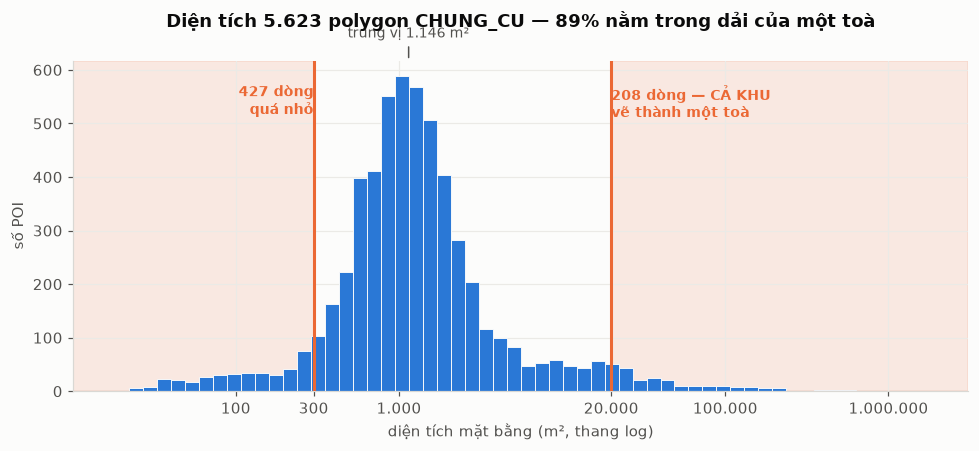

In [31]:
# [DATA] sinh cột: area_band
# Bước 4A — DIỆN TÍCH: dấu vân tay rẻ nhất để biết một dòng có phải MỘT toà không.
#
# Một toà chung cư ở VN nằm gọn trong dải ~300–20.000 m² mặt bằng. Ra khỏi dải:
#   - quá nhỏ  → không đủ chỗ cho một toà (lõi thang, ô vẽ lỗi, nhà lẻ gắn nhầm tag)
#   - quá to   → không phải MỘT toà mà là CẢ KHU (Times City, Gamuda, khu TĐC)
# Vế "quá to" là rò rỉ ranh giới lớp: những dòng đó thuộc KHU_DO_THI, không thuộc đây.
import matplotlib.pyplot as plt

# Bảng màu đã chạy validator (light, all-pairs): CVD ΔE 9,2 · normal 24,0 → PASS.
# #1baf7a dưới 3:1 trên nền sáng nên MỌI cột đều gắn nhãn số trực tiếp — không đọc bằng màu.
# Định nghĩa MỘT lần ở đây, mọi cell vẽ sau dùng lại.
BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"
GRAY = "#b8b7b2"  # "không đủ dữ liệu" — trung tính, cố ý KHÔNG cấp một hue cho trạng thái này
INK, MUTED, BG = "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "savefig.facecolor": BG,
        "axes.edgecolor": "#d9d8d4",
        "axes.grid": True,
        "grid.color": "#ebeae6",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "text.color": INK,
        "axes.labelcolor": MUTED,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
    }
)


def fmt(x, n=0):
    """Số kiểu Việt: dấu chấm ngăn nghìn."""
    return f"{x:,.{n}f}".translate(str.maketrans(",.", ".,"))


AREA_MIN, AREA_MAX = 300, 20_000
apt = clean[clean["label"].eq("CHUNG_CU")].copy()
areas = apt.loc[apt["is_area"], "area_m2"]

for lo, hi, band in [
    (0, AREA_MIN, f"< {fmt(AREA_MIN)} m² — quá nhỏ cho một toà"),
    (AREA_MIN, AREA_MAX, "dải hợp lý của MỘT toà"),
    (AREA_MAX, np.inf, f"> {fmt(AREA_MAX)} m² — là CẢ KHU, không phải một toà"),
]:
    m = (areas >= lo) & (areas < hi)
    print(f"  {band:45s} {m.sum():5,} ({m.mean():5.1%})")
print(f"  {'node, không có polygon → không đo được':45s} {(~apt['is_area']).sum():5,}")

# Cột hoá luôn ba dải — để downstream lọc được mà không phải tự tính lại ngưỡng.
apt["area_band"] = pd.cut(
    apt["area_m2"].where(apt["is_area"]),
    [0, AREA_MIN, AREA_MAX, np.inf],
    labels=["qua_nho", "hop_ly", "ca_khu"],
)

print("\n== 8 dòng to nhất: tên nói thẳng đây là khu, không phải toà ==")
print(
    apt[apt["is_area"]].nlargest(8, "area_m2")[["name", "area_m2", "levels", "building"]].to_string()
)
print(f"\n== nhỏ nhất mà vẫn mang building=apartments: {(areas < 100).sum()} dòng < 100 m² ==")
print(
    f"   {apt.loc[apt['is_area'] & (apt['area_m2'] < 100), 'name'].isna().mean():.0%} trong số đó KHÔNG có tên"
    f" — không có gì để đối chứng, phải soi tay hoặc bỏ"
)

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.log10(areas)
ax.hist(x, bins=64, color=BLUE, edgecolor=BG, linewidth=0.6)
for cut in (AREA_MIN, AREA_MAX):
    ax.axvline(np.log10(cut), color=ORANGE, linewidth=2, zorder=5)
ax.axvspan(x.min(), np.log10(AREA_MIN), color=ORANGE, alpha=0.13, zorder=0)
ax.axvspan(np.log10(AREA_MAX), x.max(), color=ORANGE, alpha=0.13, zorder=0)

n_small = int((areas < AREA_MIN).sum())
n_big = int((areas >= AREA_MAX).sum())
ax.annotate(
    f"{fmt(n_small)} dòng\nquá nhỏ",
    (np.log10(AREA_MIN), 0.93),
    xycoords=("data", "axes fraction"),
    ha="right",
    va="top",
    fontsize=9,
    color=ORANGE,
    fontweight="bold",
)
ax.annotate(
    f"{fmt(n_big)} dòng — CẢ KHU\nvẽ thành một toà",
    (np.log10(AREA_MAX), 0.93),
    xycoords=("data", "axes fraction"),
    ha="left",
    va="top",
    fontsize=9,
    color=ORANGE,
    fontweight="bold",
)
ax.annotate(
    f"trung vị {fmt(areas.median())} m²",
    (np.log10(areas.median()), 1.0),
    xytext=(np.log10(areas.median()), 1.06),
    xycoords=("data", "axes fraction"),
    textcoords=("data", "axes fraction"),
    ha="center",
    va="bottom",
    fontsize=9,
    color=MUTED,
    arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=1),
)

ticks = [10, 100, 300, 1_000, 20_000, 100_000, 1_000_000]
ax.set_xticks(np.log10(ticks))
ax.set_xticklabels([fmt(v) for v in ticks])
ax.set_xlim(x.min(), x.max())
ax.set_xlabel("diện tích mặt bằng (m², thang log)")
ax.set_ylabel("số POI")
ax.set_title(
    f"Diện tích {fmt(len(areas))} polygon CHUNG_CU"
    f" — {(areas.between(AREA_MIN, AREA_MAX)).mean():.0%} nằm trong dải của một toà",
    pad=22,
)
fig.tight_layout()
plt.show()

In [32]:
# Nhóm rủi ro nhất: polygon NHỎ hơn ngưỡng một toà — có thể là nhánh tuyển sai. Soi tay.
apt_small = apt[apt["is_area"] & (apt["area_m2"] < AREA_MIN)].copy()
apt_small

,uid,osm_type,osm_id,is_area,lat,lng,area_m2,geometry_wkb,h3_r8,name,...,historic,natural,waterway,power,aeroway,railway,barrier,craft,mixed_use,area_band
112344,way:165491092,way,165491092,True,10.776451,106.704278,154.895264,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,8865b56629fffff,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False,qua_nho
113260,way:210721329,way,210721329,True,21.007272,105.848586,226.895551,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,88415cb4c5fffff,Z9,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False,qua_nho
113294,way:211063944,way,211063944,True,15.890312,108.321160,90.017262,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,8841643097fffff,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False,qua_nho
113296,way:211221361,way,211221361,True,15.881655,108.325529,73.371967,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,8841643091fffff,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False,qua_nho
113326,way:212150838,way,212150838,True,15.881329,108.325275,59.022275,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,8841643091fffff,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False,qua_nho
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193472,way:1540903510,way,1540903510,True,10.775732,106.653680,235.348328,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",8865b566e7fffff,Lô C2,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False,qua_nho
193473,way:1540903511,way,1540903511,True,10.776187,106.653845,248.410740,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,8865b566e7fffff,Lô B1,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False,qua_nho
193474,way:1540903512,way,1540903512,True,10.775927,106.654126,248.362808,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",8865b566e7fffff,Lô B3,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False,qua_nho
193475,way:1540903513,way,1540903513,True,10.775671,106.653878,248.363019,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,8865b566e7fffff,Lô C3,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False,qua_nho


không có gì bất thường với nhỏ, tuy nhiên cần review lại với các chung cư vực ngưỡng

xét xem có toà nào ở bên trong không

208 dòng CHUNG_CU lớn hơn 20.000 m² — trung vị 3,7 ha
verdict
LÀ KHU — sai lớp              158
một toà, vẽ rộng               27
trống ruột — chưa kết luận     23

== LÀ KHU: nhiều công trình riêng biệt bên trong, không thể là một toà ==
                                              name    ha  n_building  n_apt  n_service          province_name
142748                               Gamuda Garden  63.5          10      3         27       Thành phố Hà Nội
156044                              ParkCity Hanoi  49.0           7      1         24       Thành phố Hà Nội
131069                         Vinhomes Times City  36.1          36     29        227       Thành phố Hà Nội
144111                          Vinhomes Green Bay  32.4          14      3         43       Thành phố Hà Nội
184254                   Khu dân cư Palm Residence  28.3           3      1          9  Thành phố Hồ Chí Minh
183959  Ký túc xá Khu B ĐHQG Thành phố Hồ Chí Minh  21.8          32     31         21  Thành phố Hồ 

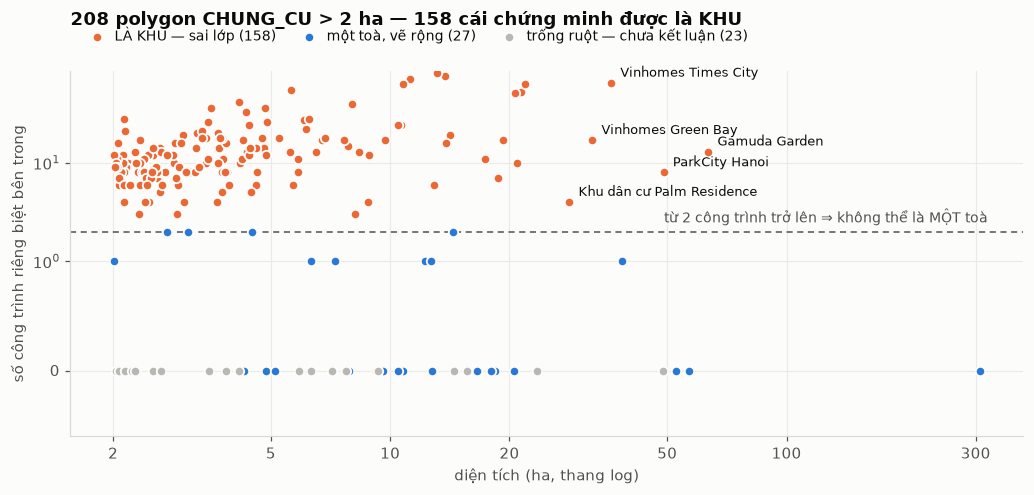

In [33]:
# [DATA] sinh cột: verdict
# Bước 4D — các dòng > 2 ha: có thật là KHU không, hay chỉ là một toà vẽ rộng tay?
#
# "Có POI bên trong" CHƯA đủ để kết luận là khu — một toà chung cư đơn lẻ vẫn chứa
# siêu thị, phòng gym, quán cà phê ở tầng đế. Bằng chứng CỨNG là thứ khác:
#   nhiều CÔNG TRÌNH RIÊNG BIỆT nằm bên trong. Một toà không thể chứa nhiều toà.
# Nên đếm riêng: nhà (building=*), chung cư đã lọc sạch, và dịch vụ.
#
# Và vẫn giữ nguyên cái bẫy của bước 5B: bên trong trống KHÔNG có nghĩa là "chỉ một toà" —
# có thể OSM chưa vẽ ruột. Nhóm đó phải để riêng, không được kết luận.
#
# Đây là PHÉP ĐO, không gán lại nhãn: thực địa cho thấy cả hai kiểu map đều tồn tại
# (n polygon = n toà, và cả khu chỉ có một viền) — chờ mentor đánh giá trước khi quyết.
from shapely import wkb
from shapely.geometry import Point
from shapely.strtree import STRtree

# ── Hạ tầng không gian dùng chung cho 4D / 4E / 5B — dựng MỘT lần ──
POINTS = [Point(x, y) for x, y in zip(poi["lng"].values, poi["lat"].values)]
TREE = STRtree(POINTS)
POI_UID = poi["uid"].values
IS_BUILDING = poi["building"].notna().values
IS_SERVICE = poi["tags_dict"].map(
    lambda t: bool({"amenity", "shop", "office", "leisure", "tourism"} & t.keys())
).values


def poi_inside(geom, self_uid=None):
    """Chỉ số các POI có toạ độ nằm TRONG geom (loại chính nó theo uid)."""
    idx = TREE.query(geom)
    idx = idx[[geom.contains(POINTS[j]) for j in idx]] if len(idx) else np.array([], int)
    if self_uid is not None and len(idx):
        idx = idx[POI_UID[idx] != self_uid]
    return idx


apt_uids = set(clean.loc[clean["label"].eq("CHUNG_CU"), "uid"])
IS_APT = poi["uid"].isin(apt_uids).values

apt_big = apt[apt["is_area"] & (apt["area_m2"] > AREA_MAX)].copy()
apt_big["ha"] = apt_big["area_m2"] / 1e4
print(
    f"{len(apt_big)} dòng CHUNG_CU lớn hơn {fmt(AREA_MAX)} m² — trung vị {fmt(apt_big['ha'].median(), 1)} ha"
)

rows = []
for i, w in zip(apt_big.index, apt_big["geometry_wkb"]):
    geom = wkb.loads(bytes(w))
    inside = poi_inside(geom, self_uid=apt_big.at[i, "uid"])
    rows.append((i, int(IS_BUILDING[inside].sum()), int(IS_APT[inside].sum()), int(IS_SERVICE[inside].sum())))

counts = pd.DataFrame(rows, columns=["idx", "n_building", "n_apt", "n_service"]).set_index("idx")
apt_big = apt_big.join(counts)

# ≥2 công trình riêng biệt bên trong ⇒ không thể là MỘT toà.
is_complex = (apt_big["n_building"] >= 2) | (apt_big["n_apt"] >= 2)
empty_core = ~is_complex & apt_big[["n_building", "n_apt", "n_service"]].sum(axis=1).eq(0)
apt_big["verdict"] = np.select(
    [is_complex, empty_core],
    ["LÀ KHU — sai lớp", "trống ruột — chưa kết luận"],
    default="một toà, vẽ rộng",
)
print(apt_big["verdict"].value_counts().to_string())

print("\n== LÀ KHU: nhiều công trình riêng biệt bên trong, không thể là một toà ==")
print(
    apt_big[is_complex]
    .nlargest(12, "ha")[["name", "ha", "n_building", "n_apt", "n_service", "province_name"]]
    .round(1)
    .to_string()
)

print("\n== trống ruột: to bất thường nhưng OSM chưa vẽ gì bên trong — để riêng, không kết luận ==")
print(f"{empty_core.sum()} dòng, ví dụ:", apt_big.loc[empty_core, "name"].dropna().head(6).tolist())

fig, ax = plt.subplots(figsize=(9.5, 4.6))
VERDICT_COLOR = {"LÀ KHU — sai lớp": ORANGE, "một toà, vẽ rộng": BLUE, "trống ruột — chưa kết luận": GRAY}
for verdict, color in VERDICT_COLOR.items():
    m = apt_big["verdict"].eq(verdict)
    ax.scatter(
        apt_big.loc[m, "ha"],
        apt_big.loc[m, "n_building"] + apt_big.loc[m, "n_apt"],
        s=38,
        color=color,
        edgecolor=BG,
        linewidth=1.2,
        label=f"{verdict} ({m.sum()})",
        zorder=3,
    )
ax.axhline(2, color=MUTED, linewidth=1, linestyle=(0, (4, 3)), zorder=2)
ax.annotate(
    "từ 2 công trình trở lên ⇒ không thể là MỘT toà",
    (ax.get_xlim()[1], 2.3),
    ha="right",
    va="bottom",
    fontsize=9,
    color=MUTED,
)
for _, r in apt_big[is_complex].nlargest(5, "ha").iterrows():
    if pd.notna(r["name"]):
        ax.annotate(
            r["name"],
            (r["ha"], r["n_building"] + r["n_apt"]),
            xytext=(6, 4),
            textcoords="offset points",
            fontsize=8.5,
            color=INK,
        )
ax.set_xscale("log")
ax.set_yscale("symlog", linthresh=1)
ax.set_ylim(-0.6, None)  # symlog vẽ cả nhánh âm, ở đây vô nghĩa vì số công trình ≥ 0
xticks = [2, 5, 10, 20, 50, 100, 300]
ax.set_xticks(xticks)
ax.set_xticklabels([fmt(v) for v in xticks])
ax.minorticks_off()
ax.set_xlabel("diện tích (ha, thang log)")
ax.set_ylabel("số công trình riêng biệt bên trong")
ax.set_title(
    f"{len(apt_big)} polygon CHUNG_CU > 2 ha — {is_complex.sum()} cái chứng minh được là KHU",
    loc="left",
    pad=30,
)
# chú giải ra NGOÀI khung: góc trên trái là chỗ điểm dày nhất
ax.legend(
    frameon=False,
    fontsize=9,
    ncol=3,
    loc="lower left",
    bbox_to_anchor=(0, 1.04),
    handletextpad=0.3,
    columnspacing=1.4,
)
fig.tight_layout()
plt.show()

In [34]:
# [QA] không sinh cột — phép đo một lần, kết luận đã ghi vào README
# Bước 4E — ngưỡng "một toà" là bao nhiêu? Để DỮ LIỆU trả lời, đừng đoán.
#
# 2 ha (20.000 m²) là con số đặt tay ở 4A và nó quá rộng thật. Cách chốt lại:
# quét ngưỡng theo từng bậc 500 m², mỗi bậc đếm bao nhiêu polygon chứa ≥2 CHUNG_CU
# khác bên trong. Một toà không chứa được hai toà, nên bậc nào tỷ lệ đó bắt đầu
# nhấc khỏi 0 chính là chỗ "một toà" hết hợp lý.
#
# Kết quả là PHÉP ĐO tham khảo — chưa gán lại nhãn (cùng lý do với 4D: chờ mentor).
geoms = apt[apt["is_area"] & apt["geometry_wkb"].notna()].copy()
geoms["_geom"] = [wkb.loads(bytes(x)) for x in geoms["geometry_wkb"]]
geoms = geoms[[g.is_valid and g.area > 0 for g in geoms["_geom"]]]

n_apt_inside = []
for i, g in zip(geoms.index, geoms["_geom"]):
    inside = poi_inside(g, self_uid=geoms.at[i, "uid"])
    n_apt_inside.append(int(IS_APT[inside].sum()))
geoms["n_apt_inside"] = n_apt_inside

STEP, CAP = 500, 15_000  # cắt ở 15.000 m²: trên mức đó mỗi bậc chỉ còn vài polygon
geoms["bin"] = (geoms["area_m2"] // STEP).astype(int) * STEP
q = (
    geoms[geoms["bin"] < CAP]
    .groupby("bin")
    .agg(n=("n_apt_inside", "size"), ge2=("n_apt_inside", lambda s: (s >= 2).sum()))
)
q["ratio"] = q["ge2"] / q["n"]
q = q.reindex(range(0, CAP, STEP), fill_value=0)

beyond = geoms[geoms["bin"] >= CAP]
print(
    f"cắt biểu đồ ở {fmt(CAP)} m² — bỏ ra ngoài khung {len(beyond)} polygon"
    f" (trong đó {(beyond['n_apt_inside'] >= 2).sum()} cái chứa ≥2 chung cư)"
)

LIFT = q.index[(q["ratio"] >= 0.05) & (q["n"] >= 20)].min()  # bậc đầu tiên tỷ lệ vượt 5%
MAJORITY = q.index[(q["ratio"] >= 0.5) & (q["n"] >= 10)].min()  # bậc đầu tiên quá bán
print(f"\nbậc đầu tiên vượt 5%   : {fmt(LIFT)} m²  ({q.at[LIFT, 'ge2']}/{q.at[LIFT, 'n']})")
print(f"bậc đầu tiên quá bán   : {fmt(MAJORITY)} m²  ({q.at[MAJORITY, 'ge2']}/{q.at[MAJORITY, 'n']})")
print(
    f"\ntrong nhóm KHÔNG chứa chung cư nào: p90 = {fmt(geoms.loc[geoms['n_apt_inside'].eq(0), 'area_m2'].quantile(0.9))} m²"
)
print(
    f"trong nhóm chứa ≥2 chung cư       : p5  = {fmt(geoms.loc[geoms['n_apt_inside'] >= 2, 'area_m2'].quantile(0.05))} m²"
)
print()
print(q.head(12).assign(ratio=lambda d: (d["ratio"] * 100).round(1)).to_string())

cắt biểu đồ ở 15.000 m² — bỏ ra ngoài khung 287 polygon (trong đó 207 cái chứa ≥2 chung cư)

bậc đầu tiên vượt 5%   : 3.000 m²  (8/111)
bậc đầu tiên quá bán   : 6.500 m²  (12/24)

trong nhóm KHÔNG chứa chung cư nào: p90 = 2.572 m²
trong nhóm chứa ≥2 chung cư       : p5  = 3.768 m²

         n  ge2  ratio
bin                   
0      815    0    0.0
500   1624    0    0.0
1000  1130    1    0.1
1500   659    2    0.3
2000   342    4    1.2
2500   199    4    2.0
3000   111    8    7.2
3500    60    6   10.0
4000    56   10   17.9
4500    56   16   28.6
5000    29    9   31.0
5500    26   10   38.5


Tôi review qua, xem cả POI ở trên map tôi có các đánh giá sau:
- một số khu đô thị lớn chỉ có một gộp lớn mà không có POI chi tiết là các toà nhà ở trong đó
- một số lại có toà nhà ở trong
-> hiện tại không có huớng giải quyết cụ thể, cần hỗ trợ thêm


### Bước 5 — soi lớp KHU_DO_THI qua đúng ba trục đó

Cùng bộ ba trục của bước 4, nhưng ở lớp này chúng cho ra một kết luận khác hẳn về
BẢN CHẤT. Ở CHUNG_CU, vấn đề nằm ở từng dòng (mảnh, nhiễu, lệch ranh). Ở đây vấn đề
nằm ở **nhãn của cả lớp**: 86% polygon vô danh và 71% mang đúng một tag
`landuse=residential` — "đất ở", một khái niệm rộng hơn "khu đô thị" rất nhiều.

Trục **ruột** ở lớp này còn phải thêm một bước mà lớp CHUNG_CU không cần: đối chứng
**vành đai**. Polygon rỗng có thể vì chưa xây, cũng có thể vì OSM chưa vẽ tới — hai
chuyện hoàn toàn khác nhau, và không tách ra thì mọi con số "khu rỗng" đều vô nghĩa.


  < 1 ha — bằng một lô đất, không thể là khu       1,612 (44.2%)
  1–5 ha — nhỏ hơn mọi KĐT có tên                    980 (26.9%)
  5–300 ha — dải quy mô của một khu thật           1,019 (27.9%)
  > 300 ha — to bằng cả xã, nghi ranh giới hành chính    35 ( 1.0%)

== 6 polygon to nhất KHÔNG có tên — không có gì để đối chứng ==
            ha  n_tags residential        province_name
129905  2216.2       1         NaN  Thành phố Hải Phòng
191110  1423.9       1         NaN    Thành phố Cần Thơ
191365  1167.8       1         NaN        Tỉnh Đồng Nai
134385  1082.7       1         NaN    Thành phố Đà Nẵng
153406  1053.3       1         NaN        Tỉnh Đồng Nai
132802  1039.2       1         NaN  Thành phố Hải Phòng

== để so sánh: 6 KĐT có tên, to nhất ==
                                                     name     ha          province_name
184034  Khu đô thị Đại học Quốc gia Thành phố Hồ Chí Minh  601.1  Thành phố Hồ Chí Minh
148732                                Khu đô thị Thanh Hà  360.

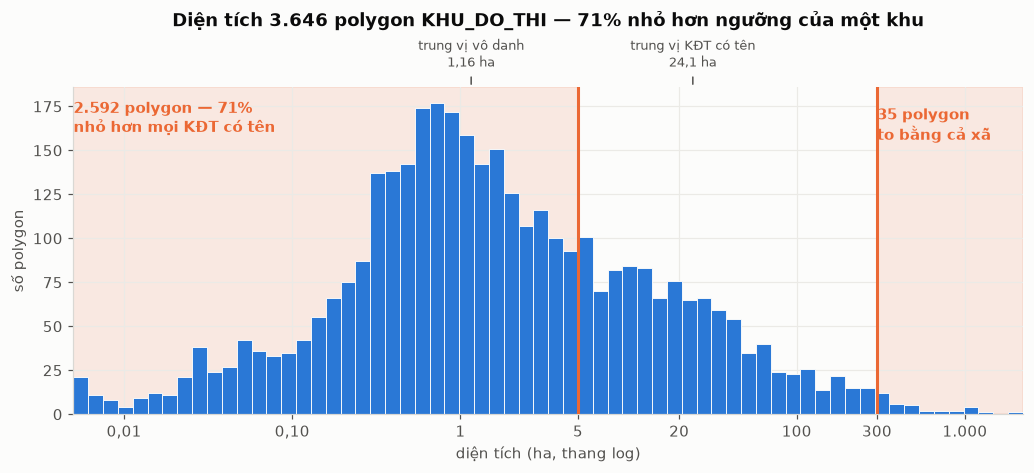

In [35]:
# [DATA] sinh cột: name_group
# Bước 5A — DIỆN TÍCH: trục rẻ nhất, và ở lớp này nó lật ngay một chuyện lớn.
#
# Một khu đô thị VN có quy mô hàng chục ha. Dưới ~5 ha thì dù tag là gì, vật thể đó
# là MỘT Ô ĐẤT Ở, không phải một khu. Trên ~300 ha thì phải nghi ngược lại: polygon
# đang ôm cả xã, tức là ranh giới hành chính bị vẽ thành đất ở.
# (Bảng màu + rcParams + fmt() đã định nghĩa ở bước 4A, dùng lại.)

HA_MIN, HA_MAX = 5, 300  # ha
kdt = clean[clean["label"].eq("KHU_DO_THI")].copy()
kdt["ha"] = kdt["area_m2"] / 1e4

# Nhóm theo TÊN — dùng lại ở 5B và 5C, định nghĩa một lần ở đây.
_t = kdt["name_norm"].fillna("")
kdt["name_group"] = np.select(
    [
        _t.str.contains(r"khu do thi|\bkdtm?\b|garden city", na=False),
        _t.str.contains(r"khu dan cu|\bkdc\b|khu nha o", na=False),
        kdt["name"].notna(),
    ],
    ["tên nói 'khu đô thị'", "tên nói 'khu dân cư'", "có tên khác"],
    default="KHÔNG có tên",
)

ha = kdt.loc[kdt["is_area"], "ha"]
for lo, hi, band in [
    (0, 1, "< 1 ha — bằng một lô đất, không thể là khu"),
    (1, HA_MIN, "1–5 ha — nhỏ hơn mọi KĐT có tên"),
    (HA_MIN, HA_MAX, "5–300 ha — dải quy mô của một khu thật"),
    (HA_MAX, np.inf, "> 300 ha — to bằng cả xã, nghi ranh giới hành chính"),
]:
    m = (ha >= lo) & (ha < hi)
    print(f"  {band:48s} {m.sum():5,} ({m.mean():5.1%})")

print("\n== 6 polygon to nhất KHÔNG có tên — không có gì để đối chứng ==")
noname = kdt[kdt["name"].isna()].nlargest(6, "ha")[["ha", "n_tags", "residential", "province_name"]]
print(noname.round(1).to_string())

print("\n== để so sánh: 6 KĐT có tên, to nhất ==")
print(
    kdt[kdt["name_group"].eq("tên nói 'khu đô thị'")]
    .nlargest(6, "ha")[["name", "ha", "province_name"]]
    .round(1)
    .to_string()
)

fig, ax = plt.subplots(figsize=(9.5, 4.4))
x = np.log10(ha.clip(lower=0.005))
ax.hist(x, bins=64, color=BLUE, edgecolor=BG, linewidth=0.6)
for cut in (HA_MIN, HA_MAX):
    ax.axvline(np.log10(cut), color=ORANGE, linewidth=2, zorder=5)
ax.axvspan(x.min(), np.log10(HA_MIN), color=ORANGE, alpha=0.13, zorder=0)
ax.axvspan(np.log10(HA_MAX), x.max(), color=ORANGE, alpha=0.13, zorder=0)

ax.annotate(
    f"{fmt((ha < HA_MIN).sum())} polygon — {(ha < HA_MIN).mean():.0%}\nnhỏ hơn mọi KĐT có tên",
    (x.min(), 0.96),  # neo mép trái: quanh ngưỡng 5 ha cột đang cao, đặt ở đó sẽ đè lên dữ liệu
    xycoords=("data", "axes fraction"),
    ha="left",
    va="top",
    fontsize=9.5,
    color=ORANGE,
    fontweight="bold",
)
ax.annotate(
    f"{fmt((ha >= HA_MAX).sum())} polygon\nto bằng cả xã",
    (np.log10(HA_MAX), 0.94),
    xycoords=("data", "axes fraction"),
    ha="left",
    va="top",
    fontsize=9.5,
    color=ORANGE,
    fontweight="bold",
)
for note, val in [
    (
        "trung vị KĐT có tên\n24,1 ha",
        kdt.loc[kdt["name_group"].eq("tên nói 'khu đô thị'"), "ha"].median(),
    ),
    ("trung vị vô danh\n1,16 ha", kdt.loc[kdt["name_group"].eq("KHÔNG có tên"), "ha"].median()),
]:
    ax.annotate(
        note,
        (np.log10(val), 1.0),
        xytext=(np.log10(val), 1.05),
        xycoords=("data", "axes fraction"),
        textcoords=("data", "axes fraction"),
        ha="center",
        va="bottom",
        fontsize=8.5,
        color=MUTED,
        arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=1),
    )

ticks = [0.01, 0.1, 1, 5, 20, 100, 300, 1000]
ax.set_xticks(np.log10(ticks))
ax.set_xticklabels([fmt(v, 2 if v < 1 else 0) for v in ticks])
ax.set_xlim(x.min(), x.max())
ax.set_xlabel("diện tích (ha, thang log)")
ax.set_ylabel("số polygon")
ax.set_title(
    f"Diện tích {fmt(len(ha))} polygon KHU_DO_THI"
    f" — {(ha < HA_MIN).mean():.0%} nhỏ hơn ngưỡng của một khu",
    pad=40,
)
fig.tight_layout()
plt.show()

status                CÓ RUỘT  MÙ OSM  RỖNG THẬT
name_group                                      
tên nói 'khu đô thị'       67      12         19
tên nói 'khu dân cư'       42      21         29
có tên khác               106     126         80
KHÔNG có tên              556    2184        416

64% số polygon rơi vào vùng OSM chưa map — đây là TRẦN độ tin cậy của lớp này, không phải kết quả phân loại.

== ỨNG VIÊN KHAI KHỐNG: rỗng thật, > 10 ha, có tên ==
34 dòng — polygon lớn, bên trong không một mái nhà, mà ngay bên cạnh thì có:
                            name     ha  n_building  n_service  ring_building  ring_service          province_name
155707   Khu đô thị Bắc Sông Cấm  311.7         0.0        1.0           27.0         142.0    Thành phố Hải Phòng
185065  KĐT Vinhomes Golden City  240.6         0.0        0.0            1.0           4.0    Thành phố Hải Phòng
182755                   Cái Dăm   94.5         0.0        2.0           41.0          44.0        Tỉnh Quảng Ninh
1467

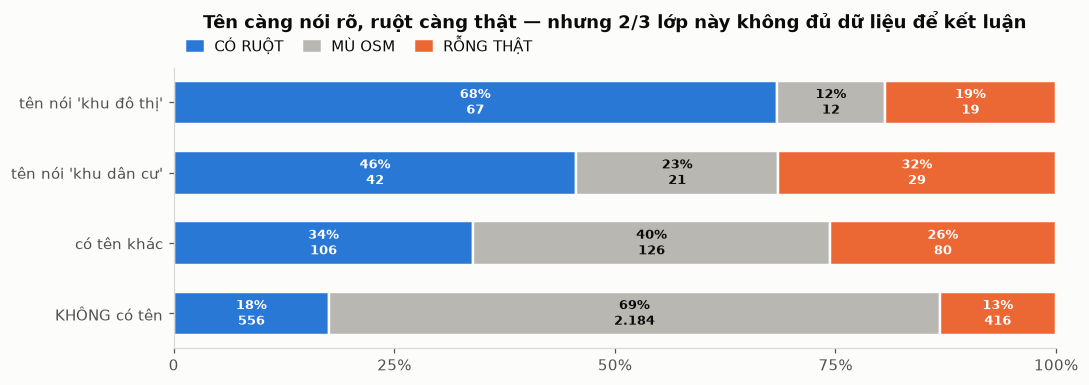

In [36]:
# [DATA] sinh cột: status, n_building, n_service, ring_*
# Bước 5B — RUỘT: khu thật thì có người ở, và người ở để lại dấu vết.
#
# Đếm POI nằm BÊN TRONG mỗi polygon. Đây là nhân chứng độc lập: bước 3 đã xoá quán,
# trường, chợ, trạm buýt khỏi lớp này, nên chúng không phải dòng ta đang xét.
#
# Cái bẫy phải né: "rỗng" có HAI nguyên nhân khác hẳn nhau — chưa xây, và OSM chưa vẽ.
# Nên mỗi polygon còn đo thêm một VÀNH ĐAI bao quanh (dày ~nửa cạnh, diện tích cùng bậc).
# Vành đai cũng rỗng ⇒ vùng đó chưa ai map ⇒ sự vắng mặt bên trong KHÔNG phải bằng chứng.
# (TREE / poi_inside / IS_BUILDING / IS_SERVICE dựng ở bước 4D, dùng lại.)

g = kdt[kdt["geometry_wkb"].notna()].copy()
g["_geom"] = [wkb.loads(bytes(x)) for x in g["geometry_wkb"]]
g = g[[x.is_valid and x.area > 0 for x in g["_geom"]]]

rows = []
for i, geom in zip(g.index, g["_geom"]):
    inside = poi_inside(geom, self_uid=g.at[i, "uid"])
    ring = geom.buffer(np.sqrt(geom.area) * 0.5).difference(geom)
    ring_inside = poi_inside(ring)
    rows.append(
        (
            i,
            int(IS_BUILDING[inside].sum()),
            int(IS_SERVICE[inside].sum()),
            int(IS_BUILDING[ring_inside].sum()),
            int(IS_SERVICE[ring_inside].sum()),
        )
    )

counts = pd.DataFrame(
    rows, columns=["idx", "n_building", "n_service", "ring_building", "ring_service"]
).set_index("idx")
kdt = kdt.join(counts)

# CÓ RUỘT   : có nhà, hoặc ≥3 dịch vụ (nhiều nơi OSM vẽ quán mà chưa vẽ nhà — Lideco là ví dụ)
# MÙ OSM    : bên trong trống VÀ vành đai cũng trống → không đủ căn cứ, không kết luận
# RỖNG THẬT : bên trong trống NHƯNG vành đai có nhà/dịch vụ → đúng là chưa có cư dân
has_core = (kdt["n_building"] > 0) | (kdt["n_service"] >= 3)
osm_blind = ~has_core & kdt["ring_building"].eq(0) & (kdt["ring_service"] <= 2)
kdt["status"] = np.select([has_core, osm_blind], ["CÓ RUỘT", "MÙ OSM"], default="RỖNG THẬT")

GROUP_ORDER = ["tên nói 'khu đô thị'", "tên nói 'khu dân cư'", "có tên khác", "KHÔNG có tên"]
STATUS_ORDER = ["CÓ RUỘT", "MÙ OSM", "RỖNG THẬT"]
table = pd.crosstab(kdt["name_group"], kdt["status"])
table = table.reindex(index=GROUP_ORDER, columns=STATUS_ORDER).fillna(0).astype(int)
print(table.to_string())
print(
    f"\n{kdt['status'].eq('MÙ OSM').mean():.0%} số polygon rơi vào vùng OSM chưa map"
    f" — đây là TRẦN độ tin cậy của lớp này, không phải kết quả phân loại."
)

print("\n== ỨNG VIÊN KHAI KHỐNG: rỗng thật, > 10 ha, có tên ==")
suspects = kdt[kdt["status"].eq("RỖNG THẬT") & (kdt["ha"] > 10) & kdt["name"].notna()]
print(f"{len(suspects)} dòng — polygon lớn, bên trong không một mái nhà, mà ngay bên cạnh thì có:")
print(
    suspects.nlargest(10, "ha")[
        ["name", "ha", "n_building", "n_service", "ring_building", "ring_service", "province_name"]
    ]
    .round(1)
    .to_string()
)

fig, ax = plt.subplots(figsize=(10, 3.6))
STATUS_COLOR = {"CÓ RUỘT": BLUE, "MÙ OSM": GRAY, "RỖNG THẬT": ORANGE}
share = table.div(table.sum(axis=1), axis=0)
left = np.zeros(len(table))
for status in STATUS_ORDER:
    v = share[status].values
    # khe 2px giữa các mảnh: viền cùng màu nền, không phải đường kẻ
    ax.barh(table.index, v, left=left, color=STATUS_COLOR[status], height=0.62, edgecolor=BG, linewidth=1.6)
    for y, (p, n) in enumerate(zip(v, table[status].values)):
        if p > 0.06:  # đủ rộng mới đặt nhãn trong mảnh
            ax.text(
                left[y] + p / 2,
                y,
                f"{p:.0%}\n{fmt(n)}",
                ha="center",
                va="center",
                fontsize=8.5,
                color="#ffffff" if status != "MÙ OSM" else INK,
                fontweight="bold",
            )
    left += v

ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(["0", "25%", "50%", "75%", "100%"])
ax.invert_yaxis()
ax.grid(visible=False)
ax.set_title(
    "Tên càng nói rõ, ruột càng thật — nhưng 2/3 lớp này không đủ dữ liệu để kết luận", pad=26
)
ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=STATUS_COLOR[s]) for s in STATUS_ORDER],
    labels=STATUS_ORDER,
    ncol=3,
    loc="lower left",
    bbox_to_anchor=(0, 1.0),
    frameon=False,
    fontsize=9.5,
    handlelength=1.1,
    columnspacing=1.4,
)
fig.tight_layout()
plt.show()

In [37]:
# [QA] không sinh cột — số liệu ở đây 5A/5B đã tính, giữ lại phần in làm bằng chứng
# Bước 5C — TÊN: và ở đây lớp KHU_DO_THI tự khai ra vấn đề của chính nó.
#
# Ở lớp CHUNG_CU, tên là thứ dễ khai khống nhất nên phải soi kỹ. Ở lớp này ngược lại:
# tên gần như KHÔNG TỒN TẠI. 86% polygon vô danh, và 71% mang đúng MỘT tag —
# `landuse=residential`, tức là "đất ở", một khái niệm rộng hơn "khu đô thị" rất nhiều
# và bao trùm cả làng xóm nông thôn.
#
# Ghép với trục diện tích ở 5A: nhóm vô danh có trung vị 1,16 ha, nhỏ hơn 20 lần
# nhóm có tên KĐT. Hai trục độc lập cùng chỉ về một kết luận: phần lớn lớp này
# KHÔNG phải khu đô thị, và cái sai nằm ở NHÃN LỚP, không nằm ở từng dòng.

group_counts = kdt["name_group"].value_counts().reindex(GROUP_ORDER).fillna(0).astype(int)
ha_median = kdt.groupby("name_group")["ha"].median().reindex(GROUP_ORDER)

print("số tag trên mỗi polygon:", kdt["n_tags"].value_counts().head(4).to_dict())
only_landuse = kdt["n_tags"].eq(1) & kdt["landuse"].eq("residential")
print(
    f"chỉ mang landuse=residential và không gì khác: {only_landuse.sum():,} ({only_landuse.mean():.0%})"
)
print(f"tag nói thẳng là đô thị (residential=urban): {kdt['residential'].eq('urban').sum()}")
print(
    f"tag nói thẳng là NÔNG THÔN / nhà lẻ (rural, single_family): "
    f"{kdt['residential'].isin(['rural', 'single_family']).sum()}"
)
print()
print(pd.DataFrame({"số polygon": group_counts, "diện tích trung vị (ha)": ha_median.round(2)}).to_string())

số tag trên mỗi polygon: {1: 2579, 2: 883, 3: 141, 4: 24}
chỉ mang landuse=residential và không gì khác: 2,579 (71%)
tag nói thẳng là đô thị (residential=urban): 89
tag nói thẳng là NÔNG THÔN / nhà lẻ (rural, single_family): 41

                      số polygon  diện tích trung vị (ha)
name_group                                               
tên nói 'khu đô thị'          98                    24.11
tên nói 'khu dân cư'          92                     6.33
có tên khác                  312                     1.58
KHÔNG có tên                3156                     1.16


### Bước 5D — siết nhãn: một lớp `KHU_DO_THI` là không trung thực

Ba bước đo trên đã chứng minh phần lớn lớp này không phải khu đô thị. Cell này không đo
thêm gì — nó chỉ **dịch bằng chứng đã có thành nhãn**, để người nhận file không phải đọc
README mới biết mình đang cầm cái gì.

In [38]:
# [DATA] sinh cột: kdt_class
# Bước 5D — siết nhãn. KHÔNG đo thêm, chỉ dịch bằng chứng của 5A/5B thành nhãn.
#
# Ngưỡng chọn theo dữ liệu, không đặt tay (số từ chính hai cell trên):
#   nhóm tên nói "khu đô thị": trung vị 4 công trình bên trong, p75 = 13
#   nhóm KHÔNG có tên        : p90 chỉ = 1 công trình
# ⇒ mốc 10 công trình nằm gọn giữa hai phân bố, không cắt qua đám đông của nhóm nào.
#
# Vì sao DAT_O KHÔNG dùng `status`: MÙ OSM nói ta không biết BÊN TRONG có gì — nó không
# ảnh hưởng tới DIỆN TÍCH, vì ranh polygon đã được vẽ ra rồi. Một ô 0,5 ha vô danh thì
# dù OSM có map kỹ tới đâu cũng không thể là một khu đô thị. Kích thước tự nó kết luận.
# TRẦN TRÊN là bắt buộc, không chỉ sàn dưới: 5A đã cảnh báo polygon > 300 ha là ranh giới
# hành chính bị vẽ thành đất ở. Không chặn trần thì "≥10 công trình" bị thoả chỉ vì polygon
# quá to — đo thử: nhóm > 300 ha có mật độ 0,030 nhà/ha, nhóm dưới 300 ha là 0,095, gấp 3 lần.
# Nhóm vượt trần được gọi đúng tên riêng thay vì nhét vào "không kết luận": ta BIẾT nó sai
# kiểu gì, chỉ là sai từ khâu vẽ chứ không phải khâu phân loại.
NB_MIN, HA_MIN_XN, HA_MAX_XN = 10, 5, 300

khai_ten = kdt["name_group"].isin(["tên nói 'khu đô thị'", "tên nói 'khu dân cư'"])
du_quy_mo = kdt["ha"].between(HA_MIN_XN, HA_MAX_XN) & (kdt["n_building"] >= NB_MIN)
qua_kho = kdt["is_area"] & (kdt["ha"] > HA_MAX_XN) & ~khai_ten

kdt["kdt_class"] = np.select(
    [
        qua_kho,                                    # to bằng cả xã, không ai khai tên → ranh hành chính
        khai_ten | du_quy_mo,                       # người map khai, HOẶC đủ quy mô + cấu trúc
        kdt["is_area"] & (kdt["ha"] < HA_MIN_XN),   # nhỏ hơn mọi KĐT có tên → là Ô ĐẤT Ở
    ],
    ["NGHI_RANH_HANH_CHINH", "KDT_XAC_NHAN", "DAT_O"],
    default="KHONG_KET_LUAN",                       # to vừa, vô danh, không đủ cấu trúc
)

print(kdt["kdt_class"].value_counts().to_string())
print()
print(pd.crosstab(kdt["kdt_class"], kdt["name_group"]).to_string())
print("\ndiện tích trung vị (ha) và số công trình trung vị theo nhãn mới:")
print(kdt.groupby("kdt_class")[["ha", "n_building"]].median().round(2).to_string())

print(f"\n{du_quy_mo.sum() - (du_quy_mo & khai_ten).sum()} dòng VÔ DANH được xác nhận"
      " nhờ quy mô + cấu trúc (bằng chứng độc lập với tên):")
print(kdt[du_quy_mo & ~khai_ten].nlargest(8, "ha")[
    ["name", "ha", "n_building", "n_service", "province_name"]].round(1).to_string())

kdt_class
DAT_O                   2537
KHONG_KET_LUAN           860
KDT_XAC_NHAN             229
NGHI_RANH_HANH_CHINH      32

name_group            KHÔNG có tên  có tên khác  tên nói 'khu dân cư'  tên nói 'khu đô thị'
kdt_class                                                                                  
DAT_O                         2316          221                     0                     0
KDT_XAC_NHAN                    25           14                    92                    98
KHONG_KET_LUAN                 785           75                     0                     0
NGHI_RANH_HANH_CHINH            30            2                     0                     0

diện tích trung vị (ha) và số công trình trung vị theo nhãn mới:
                          ha  n_building
kdt_class                               
DAT_O                   0.68         0.0
KDT_XAC_NHAN           18.15         2.0
KHONG_KET_LUAN         16.32         0.0
NGHI_RANH_HANH_CHINH  428.51        13.0

39 dòng 

### Bước 6 — bảng FINAL cho MVP: cờ hoá kết quả bước 4–5 + cờ trùng thực thể

Ghi CỜ, không ghi kết luận — chuyện toà-trong-khu vẫn chờ mentor. Mục tiêu duy nhất:
mọi phép đo của bước 4–5 phải sống trong file parquet, không chết trong RAM notebook.

In [39]:
# Bước 6 — bảng FINAL: b3 + cờ bước 4–5 + TUYỂN BỒI theo không gian (vòng 2 của bước 1).
# GHI CỜ, KHÔNG KẾT LUẬN.
#
#   verdict     (4D) : polygon CHUNG_CU > 2 ha — LÀ KHU / một toà / trống ruột; NaN = ngoài nhóm đo
#   name_group  (5A) : lớp KHU_DO_THI — tên nói gì
#   status      (5B) : lớp KHU_DO_THI — CÓ RUỘT / MÙ OSM / RỖNG THẬT
#   kdt_class   (5D) : lớp KHU_DO_THI — KDT_XAC_NHAN / DAT_O / KHONG_KET_LUAN ← DÙNG CÁI NÀY
#   area_band   (4A) : lớp CHUNG_CU — qua_nho / hop_ly / ca_khu
#   container_uid    : dòng CHUNG_CU nằm TRONG polygon CHUNG_CU khác → bản sao/mảnh; đếm thực thể thì bỏ
#   fragment_group   : (h3_r8 + tên) trùng nhau trong lớp CHUNG_CU — 1 khu vẽ thành nhiều mảnh
#   context_host_uid : dòng TUYỂN BỒI — nằm trong polygon đã xác nhận nào

final = clean.copy()
final = final.join(apt_big["verdict"])
final = final.join(apt["area_band"])
final = final.join(kdt[["name_group", "status", "kdt_class", "n_building", "n_service"]])

# --- container_uid: duyệt polygon từ TO xuống NHỎ — mỗi dòng nhận container sát nhất
container = {}
for i, geom in geoms.sort_values("area_m2", ascending=False)["_geom"].items():
    self_uid = geoms.at[i, "uid"]
    inside = poi_inside(geom, self_uid=self_uid)
    for j in inside[IS_APT[inside]]:
        container[POI_UID[j]] = self_uid

final["container_uid"] = final["uid"].map(container)
final.loc[final["label"].ne("CHUNG_CU"), "container_uid"] = None
final["context_host_uid"] = None

# --- F_CONTEXT — tuyển bồi: building thường (vòng 1 không tuyển, không tag chức năng)
# nằm TRONG polygon CHUNG_CU đã lọc sạch hoặc KĐT/KDC CÓ TÊN. Bằng chứng là VỊ TRÍ,
# độc lập với tag lẫn tên — đây là các toà kiểu "S4/D8" chỉ có mã. Phải chạy SAU bước 3
# vì cần polygon đã xác nhận, nên nó là VÒNG 2 của bước 1, không phải một bước mới.
#
# Hai chốt an toàn, thiếu là hỏng cả lớp:
#   1. building phải thuộc nhóm Ở-TẬP-TRUNG-ĐƯỢC ({yes, residential, ...}) — trong một KDC
#      có tên toàn nhà liền kề building=house, thừa kế bừa là biến cả xóm thành chung cư.
#   2. host KĐT chặn ≤ 300 ha — polygon "to bằng cả xã" (5A) là ranh hành chính trá hình,
#      thừa kế từ nó là tuyển nhầm cả một xã.
CTX_FUNC_KEYS = {"amenity", "shop", "office", "tourism", "leisure", "man_made", "historic",
                 "highway", "public_transport", "railway", "power", "natural", "craft"}
CTX_BUILDING_OK = {"yes", "residential", "apartments", "dormitory", "terrace"}
PLAIN = (
    ~poi["is_housing"]
    & poi["building"].isin(CTX_BUILDING_OK)
    & ~poi["tags_dict"].map(lambda t: bool(CTX_FUNC_KEYS & t.keys()))
).values

kdt_hosts = g[
    g["name_group"].isin(["tên nói 'khu đô thị'", "tên nói 'khu dân cư'"]) & (g["ha"] <= 300)
]
recruit_host, recruit_container = {}, {}
for host_df, is_apt_host in [
    (kdt_hosts.sort_values("area_m2", ascending=False), False),  # host to quét trước,
    (geoms.sort_values("area_m2", ascending=False), True),  # host nhỏ/cụ thể ghi đè sau
]:
    for i, geom in host_df["_geom"].items():
        host_uid = host_df.at[i, "uid"]
        inside = poi_inside(geom, self_uid=host_uid)
        for j in inside[PLAIN[inside]]:
            recruit_host[POI_UID[j]] = host_uid
            if is_apt_host:
                recruit_container[POI_UID[j]] = host_uid

recruits = poi[poi["uid"].isin(recruit_host)].copy()
recruits["label"] = "CHUNG_CU"
recruits["evidence"] = "context"
for c in ["src_tag", "src_name", "src_code", "src_kdt", "src_shape", "src_manual"]:
    recruits[c] = False
recruits["context_host_uid"] = recruits["uid"].map(recruit_host)
recruits["container_uid"] = recruits["uid"].map(recruit_container)
recruits = recruits.reindex(columns=final.columns)

print(f"tuyển bồi F_CONTEXT: {len(recruits):,} building thường trong polygon đã xác nhận"
      f" ({recruits['container_uid'].notna().sum():,} trong polygon CHUNG_CU,"
      f" {recruits['container_uid'].isna().sum():,} trong KĐT/KDC có tên)"
      f" | có tên: {recruits['name'].notna().mean():.0%}")

final = pd.concat([final, recruits])

# --- fragment_group: tên trùng trong cùng ô H3 r8 (~0,7 km²) — tính SAU tuyển bồi.
# Phạm vi H3 là bắt buộc: "Block A" ở hai đầu đất nước là hai khu khác nhau, không được gộp.
apt_named = final["label"].eq("CHUNG_CU") & final["name"].notna()
key = final.loc[apt_named, ["h3_r8", "name_norm"]].astype(str).agg("|".join, axis=1)
final["fragment_group"] = key[key.duplicated(keep=False)].reindex(final.index)

n_apt = final["label"].eq("CHUNG_CU").sum()
n_contained = final["container_uid"].notna().sum()
print(f"\nCHUNG_CU nằm trong một polygon CHUNG_CU khác: {n_contained:,} dòng"
      f" → đếm thực thể: {n_apt - n_contained:,} thay vì {n_apt:,}")
print(f"nhóm mảnh trùng tên trong cùng ô H3: {final['fragment_group'].nunique():,} nhóm,"
      f" {final['fragment_group'].notna().sum():,} dòng")

out_final = EDA_DIR / f"poi_chungcu_{SCOPE}_final.parquet"
final.drop(columns="tags_dict").to_parquet(out_final, index=False)
print(f"\nfinal: {len(final):,} dòng, {final.shape[1] - 1} cột → {out_final}")
print("\ncờ 4D (chỉ nhóm > 2 ha):", final["verdict"].value_counts().to_dict())
print("cờ 5B (chỉ KHU_DO_THI) :", final["status"].value_counts().to_dict())
print("nhãn 5D (chỉ KHU_DO_THI):", final["kdt_class"].value_counts().to_dict())
print("dải 4A (chỉ CHUNG_CU)  :", final["area_band"].value_counts().to_dict())
print("evidence:", final["evidence"].value_counts().to_dict())

tuyển bồi F_CONTEXT: 1 building thường trong polygon đã xác nhận (1 trong polygon CHUNG_CU, 0 trong KĐT/KDC có tên) | có tên: 100%

CHUNG_CU nằm trong một polygon CHUNG_CU khác: 2,186 dòng → đếm thực thể: 3,769 thay vì 5,955
nhóm mảnh trùng tên trong cùng ô H3: 153 nhóm, 325 dòng

final: 9,613 dòng, 60 cột → /home/n91ym1nhky/Work/internVSF/evcs-atlas/data/qa/eda/poi_chungcu_7tinh_final.parquet

cờ 4D (chỉ nhóm > 2 ha): {'LÀ KHU — sai lớp': 158, 'một toà, vẽ rộng': 27, 'trống ruột — chưa kết luận': 23}
cờ 5B (chỉ KHU_DO_THI) : {'MÙ OSM': 2343, 'CÓ RUỘT': 771, 'RỖNG THẬT': 544}
nhãn 5D (chỉ KHU_DO_THI): {'DAT_O': 2537, 'KHONG_KET_LUAN': 860, 'KDT_XAC_NHAN': 229, 'NGHI_RANH_HANH_CHINH': 32}
dải 4A (chỉ CHUNG_CU)  : {'hop_ly': 4988, 'qua_nho': 427, 'ca_khu': 208}
evidence: {'hard_tag': 5751, 'explicit_name': 3848, 'token_only': 13, 'context': 1}


### Bước 7 — bộ CÒN LẠI, nền cho các lớp sau

Bóc lớp chung cư + khu đô thị ra khỏi bộ gốc. Phần còn lại là đầu vào của lớp lưu trú
(khách sạn, nhà nghỉ, resort) và mọi lớp sau nữa — mỗi lớp lấy phần của mình rồi truyền
phần thừa xuống, không lớp nào phải quét lại từ đầu.

In [40]:
# [DATA] sinh file: poi_extended_<scope>_con_lai.parquet
# Bước 7 — bộ CÒN LẠI = bộ gốc TRỪ ĐÚNG các dòng đã thuộc lớp chung cư/KĐT.
#
# CHỈ trừ `final`. KHÔNG trừ phần bị 14 luật của bước 3 xoá: những dòng đó là trạm buýt,
# cửa hàng, quán ăn — và quan trọng nhất, LUẬT 5 đã loại hàng trăm KHÁCH SẠN khỏi lớp này.
# Lớp lưu trú cần đúng chúng. Trừ nhầm là tự tay chặt recall của bước kế tiếp.
da_thuoc_lop = set(final["uid"])
con_lai = poi[~poi["uid"].isin(da_thuoc_lop)].copy()

out_pool = EDA_DIR / f"poi_extended_{SCOPE}_con_lai.parquet"
con_lai.drop(columns="tags_dict").to_parquet(out_pool, index=False)

print(f"bộ gốc     : {len(poi):,}")
print(f"đã bóc ra  : {len(da_thuoc_lop):,}  (lớp chung cư + khu đô thị)")
print(f"CÒN LẠI    : {len(con_lai):,}  → {out_pool.name}")

# Đối chứng: phần bị bước 3 xoá PHẢI còn nguyên trong bộ này, nếu không là đã chặt nhầm.
_bi_xoa_con = removed["uid"].isin(con_lai["uid"]).sum()
assert _bi_xoa_con == len(removed), f"mất {len(removed) - _bi_xoa_con} dòng bị xoá khỏi bộ còn lại"
print(f"✓ {len(removed):,} dòng bị 14 luật xoá đều nằm lại trong bộ còn lại")

# Nguyên liệu sẵn có cho lớp lưu trú
_tour = con_lai["tags_dict"].map(lambda t: t.get("tourism"))
print("\nnguyên liệu lớp LƯU TRÚ trong bộ còn lại:")
print(" ", _tour.value_counts().head(8).to_dict())
print(f"  building=hotel: {con_lai['building'].eq('hotel').sum():,}"
      f" | tên có 'khách sạn/nhà nghỉ/resort':"
      f" {con_lai['name_norm'].str.contains(r'khach san|nha nghi|resort|homestay|hotel', na=False).sum():,}")

bộ gốc     : 193,509
đã bóc ra  : 9,613  (lớp chung cư + khu đô thị)
CÒN LẠI    : 183,896  → poi_extended_7tinh_con_lai.parquet


✓ 1,785 dòng bị 14 luật xoá đều nằm lại trong bộ còn lại

nguyên liệu lớp LƯU TRÚ trong bộ còn lại:
  {'hotel': 2966, 'hostel': 580, 'artwork': 504, 'attraction': 491, 'guest_house': 451, 'apartment': 438, 'viewpoint': 342, 'motel': 246}
  building=hotel: 639 | tên có 'khách sạn/nhà nghỉ/resort': 2,413


### CHỐT LỚP CHUNG CƯ + KHU ĐÔ THỊ

Đầu ra: `data/qa/eda/poi_chungcu_7tinh_final.parquet` (+ `poi_extended_7tinh_con_lai.parquet` cho lớp sau) — **9.613 dòng / 60 cột**.
Mọi bước sau **đọc `final`**, không đọc `b2`/`b3` nữa.

| Lớp | Số dòng | Ghi chú |
| --- | --- | --- |
| `CHUNG_CU` | 5.955 | nhưng chỉ **3.769 thực thể** — xem lỗi #1 |
| `KHU_DO_THI` | 3.658 | nhãn thô; **phải đọc `kdt_class`**, không đọc `label` |

`kdt_class`: `DAT_O` 2.537 · `KHONG_KET_LUAN` 860 · `KDT_XAC_NHAN` 229 · `NGHI_RANH_HANH_CHINH` 32
`evidence`: `hard_tag` 5.751 · `explicit_name` 3.848 · `token_only` 13 · `context` 1

### Lỗi CÒN LẠI — đọc trước khi dùng file

**Sai số ảnh hưởng tới con số cuối**

1. Một số chung cư nằm trong polugon của chung cư khác. Đếm thực thể phải lọc `container_uid.isna()` → 3.769.
2. Từ ý 1 thì suy ra có những chung cư nhưng chứ nhiều chung cư khác cần hướng xử lý từ mentor
3. **~93 dòng `DAT_O` thực chất là KHUÔN VIÊN KHU CHUNG CƯ, không phải đất ở.** Chúng chứa
   ≥1 toà CHUNG_CU đã xác nhận bên trong — "Sky Garden 1 & 2" chứa **20 toà**, "Masteri
   Center Point" 10 toà. Luật 5D phân `DAT_O` chỉ bằng diện tích (<5 ha) nên trượt nhóm này.
   Đã có sẵn số đo để sửa (đếm chung cư bên trong), **cố ý chưa sửa** — quyết định để lại.
